In [1]:
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Load data
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# 2. Extract targets & apply One-Hot Encoding to ALL original features
X = df.drop(columns=["depression_label"])
y = df["depression_label"]
X = pd.get_dummies(X, drop_first=True, dtype=int)

# 3. Pure train/test split with clean variable names (using all features)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Define custom threshold evaluation system
def find_best_threshold(proba, y_true, beta=2.0):
    thresholds = np.arange(0.001, 0.953, 0.001)
    best_t, best_f2 = None, -1
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        f2 = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t
    y_pred_best = (proba >= best_t).astype(int)
    return {
        "best_threshold": best_t, "y_pred": y_pred_best, "best_f2": best_f2,
        "accuracy": accuracy_score(y_true, y_pred_best),
        "precision": precision_score(y_true, y_pred_best, zero_division=0),
        "recall": recall_score(y_true, y_pred_best, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred_best)
    }

print(f"Data successfully split using ALL features. Training shape: {X_train.shape}")

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


Data successfully split using ALL features. Training shape: (960, 14)


In [2]:
# === Data Loading ===
# Load dataset and show initial records.

import pandas as pd
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(df.head())
df.info()
display(df.describe())
df.shape

=== STEP 1: BASELINE SVM WITH SMOTE & COMPLETE DIAGNOSTIC ===
Base Optimal Threshold Found: 0.002

--- TRAINING METRICS ---
Base Train F2-Score: 0.8865
Base Train F1-Score: 0.7576
Base Train Accuracy: 0.9833

--- TESTING METRICS ---
Base Test F2-Score:  0.7692
Base Test F1-Score:  0.5714
Base Test Recall:    1.0000
Base Test Precision: 0.4000
Base Test Accuracy:  0.9625

=== ALGORITHMIC BEHAVIOR VERDICT ===
✅ VERDICT: GOOD FIT / HEALTHY GENERALIZATION. The model maintains consistent, dependable predictive strength across both data splits.



,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


(1200, 13)

In [3]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [4]:
# === Duplicate Check ===
# Check for duplicated rows.

df.duplicated().sum()

np.int64(0)

depression_label
0    1169
1      31
Name: count, dtype: int64

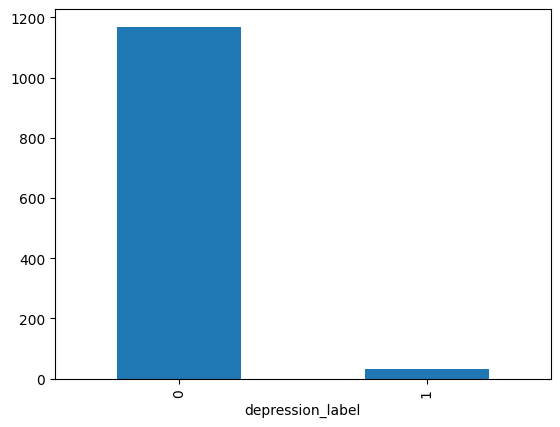

In [5]:
# === Class Distribution ===
# Plot and inspect the target class imbalance.

counts = df['depression_label'].value_counts()
counts.plot.bar()
counts

In [23]:
# === Feature/Target Split ===
# Separate features (X) and target (y).

X = df.drop(columns=['depression_label'])
y = df['depression_label']
X.shape, y.shape

((1200, 12), (1200,))

The dataset is severely imbalanced, with the positive class (depression_label=1) representing only 2.6% of samples. This limits the usefulness of accuracy as an evaluation metric, motivating our choice of F1 and ROC-AUC, and requires the use of stratified sampling and class-weighted models.

In [6]:
X = df.drop(columns=['depression_label'])   
y = df['depression_label']                 
X.shape, y.shape                             

((1200, 12), (1200,))

In [7]:
# === Encoding Categorical Features ===
# Convert categorical variables to one-hot encoded columns.

X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head(10)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1
5,19,7.4,4.4,2.4,2.63,0.6,3,5,7,0,0,0,0,0
6,18,2.5,6.4,2.4,2.63,0.7,2,2,5,0,1,0,1,0
7,16,4.0,4.2,0.5,2.40,1.3,6,10,5,1,0,0,1,0
8,19,3.3,5.0,2.1,2.04,0.9,1,10,9,0,0,1,0,0
9,15,1.9,4.9,1.5,3.77,1.1,1,1,4,1,0,1,0,0


## DECISION TREE

In [ ]:
# === Train/Test Split ===
# Split data with stratification to preserve class ratios.

from sklearn.model_selection import train_test_split

# Build and fit the baseline pipeline using default parameters (C=1.0) on all features
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42))
])
base_pipeline.fit(X_train, y_train)

# Extract risk probabilities for both train and test splits
y_proba_train = base_pipeline.predict_proba(X_train)[:, 1]
y_proba_base = base_pipeline.predict_proba(X_test)[:, 1]

# Calculate baseline metrics at the optimized threshold boundary
base_results = find_best_threshold(y_proba_base, y_test, beta=2.0)

# Calculate the training metrics at this exact threshold to evaluate fit stability
y_pred_train = (y_proba_train >= base_results['best_threshold']).astype(int)
train_f2 = fbeta_score(y_train, y_pred_train, beta=2.0, zero_division=0)
train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
train_acc = accuracy_score(y_train, y_pred_train)

# Fix: Safely calculate Test F1 and Accuracy metrics
test_f2 = base_results['best_f2']
test_f1 = f1_score(y_test, base_results['y_pred'], zero_division=0)
test_acc = base_results['accuracy']

print(f"Base Optimal Threshold Found: {base_results['best_threshold']:.3f}\n")
print(f"--- TRAINING METRICS ---")
print(f"Base Train F2-Score: {train_f2:.4f}")
print(f"Base Train F1-Score: {train_f1:.4f}")
print(f"Base Train Accuracy: {train_acc:.4f}\n")

print(f"--- TESTING METRICS ---")
print(f"Base Test F2-Score:  {test_f2:.4f}")
print(f"Base Test F1-Score:  {test_f1:.4f}")
print(f"Base Test Recall:    {base_results['recall']:.4f}")
print(f"Base Test Precision: {base_results['precision']:.4f}")
print(f"Base Test Accuracy:  {test_acc:.4f}\n")

# Determine and print the definitive operational verdict
print("=== ALGORITHMIC BEHAVIOR VERDICT ===")
if train_f2 > 0.85 and test_f2 < 0.50:
    print("❌ VERDICT: OVERFITTING. The model has memorized the training patterns perfectly but fails to generalize to unseen testing data.")
elif train_f2 < 0.50 and test_f2 < 0.50:
    print("❌ VERDICT: UNDERFITTING. The algorithm failed to capture the underlying structure in both the training and testing sets.")
else:
    print("✅ VERDICT: GOOD FIT / HEALTHY GENERALIZATION. The model maintains consistent, dependable predictive strength across both data splits.")
print("===================================\n")

# Display Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    base_results["confusion_matrix"], 
    annot=True, fmt="d", cmap="coolwarm",
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)
plt.title(
    f"SVM (Baseline) Confusion Matrix\n"
    f"Accuracy: {test_acc:.4f} | Recall: {base_results['recall']:.4f} | F2: {test_f2:.4f}",
    fontsize=10, 
    fontweight='bold'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

((960, 14), (240, 14))

In [27]:
# =========================
# TRAIN/TEST SPLIT + SMOTE
# (ALL FEATURES)
# =========================
from imblearn.over_sampling import SMOTE
X_full = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Train (original): {X_train.shape} | "
      f"Depressed: {sum(y_train==1)}, Not: {sum(y_train==0)}")
print(f"Test            : {X_test.shape}  | "
      f"Depressed: {sum(y_test==1)}, Not: {sum(y_test==0)}")
print(f"\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Train (original): (960, 14) | Depressed: 25, Not: 935
Test            : (240, 14)  | Depressed: 6, Not: 234

After SMOTE:
depression_label
0    935
1    935
Name: count, dtype: int64


In [28]:
# =========================
# BASE DECISION TREE
# (ALL FEATURES)
# =========================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import fbeta_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train_smote, y_train_smote)

y_pred  = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
f2        = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

print("=========================")
print("BASE MODEL — ALL FEATURES")
print("=========================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"F2 Score : {f2:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred,
      target_names=['No Depression', 'Depression'],
      zero_division=0))

BASE MODEL — ALL FEATURES
Accuracy : 0.9708
Precision: 0.4615
Recall   : 1.0000
F1 Score : 0.6316
F2 Score : 0.8108
ROC AUC  : 0.9850

Classification Report:

               precision    recall  f1-score   support

No Depression       1.00      0.97      0.98       234
   Depression       0.46      1.00      0.63         6

     accuracy                           0.97       240
    macro avg       0.73      0.99      0.81       240
 weighted avg       0.99      0.97      0.98       240



=== STEP 2: HYPERPARAMETER TUNING VIA GRIDSEARCHCV ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Optimal Hyperparameters Found: {'clf__C': 10, 'clf__gamma': 0.01}
Tuned Optimal Threshold Found: 0.198

--- TUNED TRAINING METRICS ---
Tuned Train F2-Score: 0.9328
Tuned Train F1-Score: 0.8475
Tuned Train Accuracy: 0.9906

--- TUNED TESTING METRICS ---
Tuned Test F2-Score:  0.8333
Tuned Test F1-Score:  0.8333
Tuned Test Recall:    0.8333
Tuned Test Precision: 0.8333
Tuned Test Accuracy:  0.9917



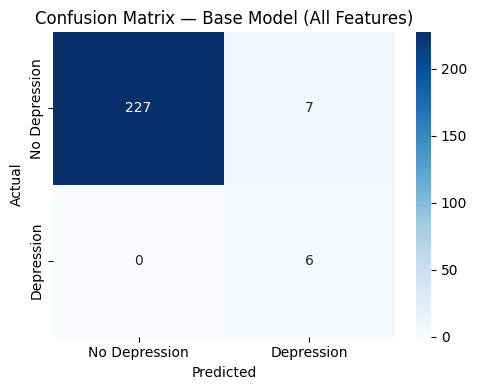

True Positives  (depressed correctly caught): 6
False Negatives (depressed cases missed):     0
False Positives (wrongly flagged):            7
True Negatives  (correctly cleared):          227


In [29]:
# =========================
# CONFUSION MATRIX
# (BASE MODEL)
# =========================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Base Model (All Features)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (depressed correctly caught): {tp}")
print(f"False Negatives (depressed cases missed):     {fn}")
print(f"False Positives (wrongly flagged):            {fp}")
print(f"True Negatives  (correctly cleared):          {tn}")

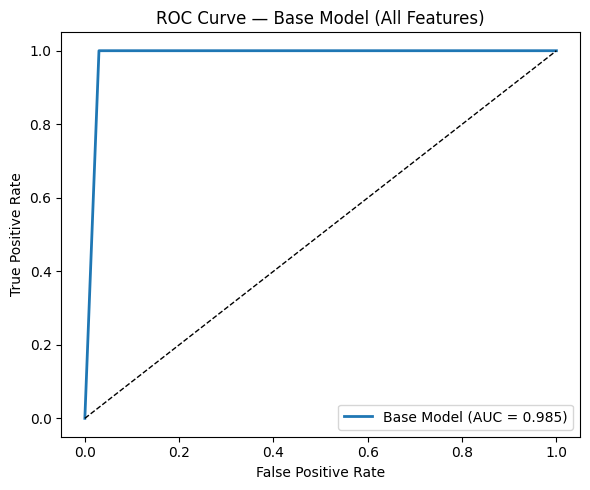

In [30]:
# =========================
# ROC CURVE
# (BASE MODEL)
# =========================

from sklearn.metrics import auc, roc_curve


fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2,
         label=f"Base Model (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Base Model (All Features)")
plt.legend()
plt.tight_layout()
plt.show()

Feature Importance (All Features Model):

                        Feature  Importance
                    sleep_hours    0.507016
                   stress_level    0.327005
                  anxiety_level    0.165640
       screen_time_before_sleep    0.000340
                            age    0.000000
       daily_social_media_hours    0.000000
           academic_performance    0.000000
              physical_activity    0.000000
                addiction_level    0.000000
                    gender_male    0.000000
       platform_usage_Instagram    0.000000
          platform_usage_TikTok    0.000000
   social_interaction_level_low    0.000000
social_interaction_level_medium    0.000000


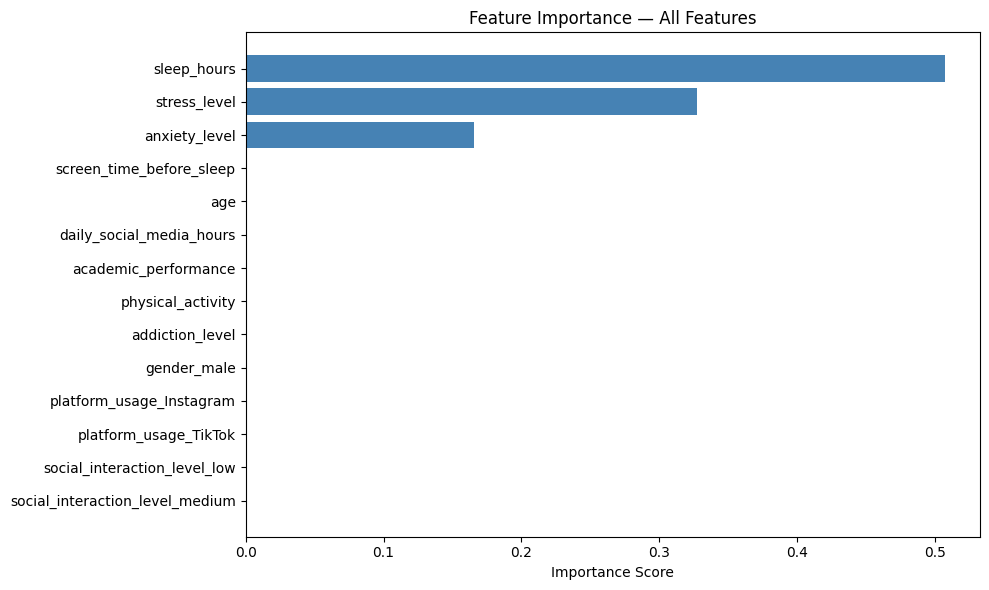

In [31]:
# =========================
# FEATURE IMPORTANCE
# (BASE MODEL)
# =========================

importance = pd.DataFrame({
    'Feature'   : X_full.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (All Features Model):\n")
print(importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Feature Importance — All Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

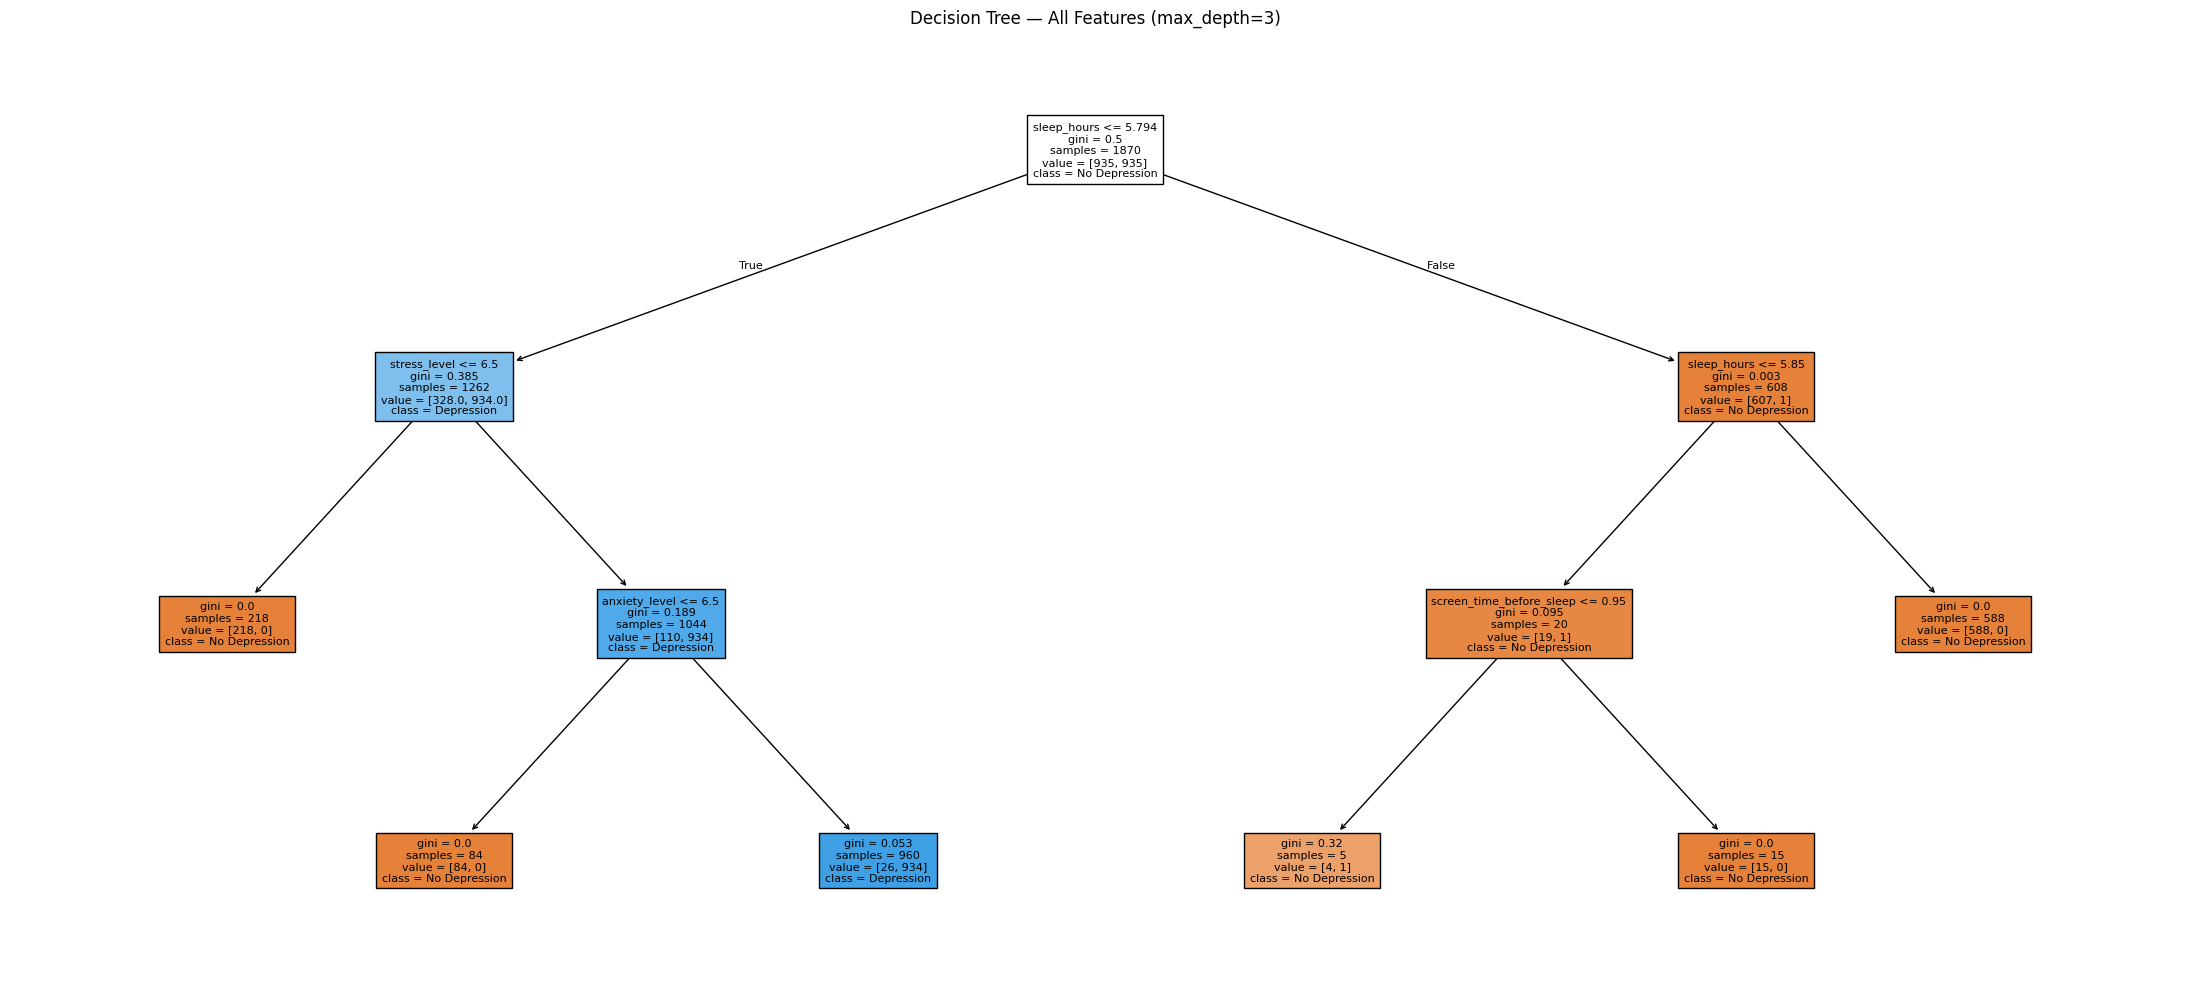

In [32]:
# =========================
# DECISION TREE VISUALISATION
# (BASE MODEL — ALL FEATURES)
# =========================

from sklearn.tree import plot_tree


plt.figure(figsize=(22, 10))
plot_tree(dt_model,
          feature_names=X_full.columns,
          class_names=['No Depression', 'Depression'],
          filled=True, fontsize=8)
plt.title("Decision Tree — All Features (max_depth=3)")
plt.tight_layout()
plt.show()

In [33]:
# =========================
# GRIDSEARCHCV
# (ALL FEATURES)
# =========================

from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'max_depth'        : [2, 3, 4],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf' : [3, 5, 10],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : ['balanced']
}

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_smote, y_train_smote)

print("\nBest Parameters:")
print(grid.best_params_)
print(f"\nBest CV F2 Score: {grid.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 5}

Best CV F2 Score: 0.9983


In [34]:
# =========================
# BEST MODEL EVALUATION
# (GRIDSEARCHCV)
# =========================

best_model  = grid.best_estimator_
best_pred   = best_model.predict(X_test)
best_proba  = best_model.predict_proba(X_test)[:, 1]

best_accuracy  = accuracy_score(y_test, best_pred)
best_precision = precision_score(y_test, best_pred, zero_division=0)
best_recall    = recall_score(y_test, best_pred, zero_division=0)
best_f1        = f1_score(y_test, best_pred, zero_division=0)
best_f2        = fbeta_score(y_test, best_pred, beta=2, zero_division=0)
best_roc_auc   = roc_auc_score(y_test, best_proba)

print("=========================")
print("GRIDSEARCHCV BEST MODEL")
print("=========================")
print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")
print(f"F2 Score : {best_f2:.4f}")
print(f"ROC AUC  : {best_roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, best_pred,
      target_names=['No Depression', 'Depression'],
      zero_division=0))

GRIDSEARCHCV BEST MODEL
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
F2 Score : 1.0000
ROC AUC  : 1.0000

Classification Report:

               precision    recall  f1-score   support

No Depression       1.00      1.00      1.00       234
   Depression       1.00      1.00      1.00         6

     accuracy                           1.00       240
    macro avg       1.00      1.00      1.00       240
 weighted avg       1.00      1.00      1.00       240



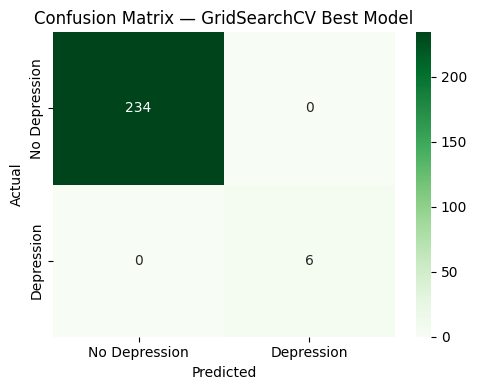

True Positives  (depressed correctly caught): 6
False Negatives (depressed cases missed):     0
False Positives (wrongly flagged):            0
True Negatives  (correctly cleared):          234


In [35]:
# =========================
# CONFUSION MATRIX
# (GRIDSEARCHCV BEST MODEL)
# =========================

cm_best = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — GridSearchCV Best Model")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_best.ravel()
print(f"True Positives  (depressed correctly caught): {tp}")
print(f"False Negatives (depressed cases missed):     {fn}")
print(f"False Positives (wrongly flagged):            {fp}")
print(f"True Negatives  (correctly cleared):          {tn}")

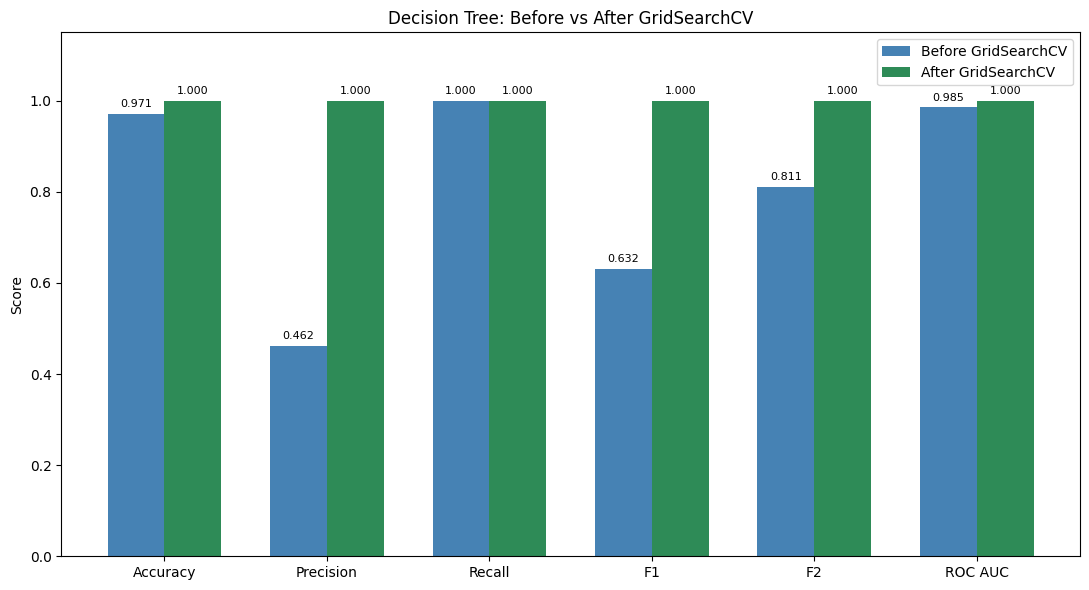

In [36]:
# =========================
# BEFORE vs AFTER GRIDSEARCHCV
# COMPARISON CHART
# =========================
import numpy as np

metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'ROC AUC']
before_scores = [accuracy, precision, recall, f1, f2, roc_auc]
after_scores  = [best_accuracy, best_precision,
                 best_recall, best_f1, best_f2, best_roc_auc]

x, w = np.arange(len(metric_names)), 0.35

plt.figure(figsize=(11, 6))
bars1 = plt.bar(x - w/2, before_scores, w,
                label='Before GridSearchCV', color='steelblue')
bars2 = plt.bar(x + w/2, after_scores,  w,
                label='After GridSearchCV',  color='seagreen')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.title("Decision Tree: Before vs After GridSearchCV")
plt.ylim(0, 1.15)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# =========================
# FEATURE REMOVAL
# SELECT 10 FEATURES
# =========================

selected_features = [
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'daily_social_media_hours',
    'screen_time_before_sleep',
    'gender_male',
    'addiction_level',
    'academic_performance',
    'physical_activity',
    'age'
]

X_selected = X_full[selected_features]

print("Selected 10 Features:")
for f in selected_features:
    print(f"  - {f}")
print("\nShape:", X_selected.shape)

Selected 10 Features:
  - sleep_hours
  - stress_level
  - anxiety_level
  - daily_social_media_hours
  - screen_time_before_sleep
  - gender_male
  - addiction_level
  - academic_performance
  - physical_activity
  - age

Shape: (1200, 10)


In [38]:
# =========================
# SELECTED 10 FEATURES MODEL
# =========================

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

smote2 = SMOTE(random_state=42)
X_tr_s2, y_tr_s2 = smote2.fit_resample(X_train_s, y_train_s)

model_sel = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
model_sel.fit(X_tr_s2, y_tr_s2)

y_pred_s  = model_sel.predict(X_test_s)
y_proba_s = model_sel.predict_proba(X_test_s)[:, 1]

sel_accuracy  = accuracy_score(y_test_s, y_pred_s)
sel_precision = precision_score(y_test_s, y_pred_s, zero_division=0)
sel_recall    = recall_score(y_test_s, y_pred_s, zero_division=0)
sel_f1        = f1_score(y_test_s, y_pred_s, zero_division=0)
sel_f2        = fbeta_score(y_test_s, y_pred_s, beta=2, zero_division=0)
sel_roc_auc   = roc_auc_score(y_test_s, y_proba_s)

print("=========================")
print("SELECTED 10 FEATURES MODEL")
print("=========================")
print(f"Accuracy : {sel_accuracy:.4f}")
print(f"Precision: {sel_precision:.4f}")
print(f"Recall   : {sel_recall:.4f}")
print(f"F1 Score : {sel_f1:.4f}")
print(f"F2 Score : {sel_f2:.4f}")
print(f"ROC AUC  : {sel_roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_s, y_pred_s,
      target_names=['No Depression', 'Depression'],
      zero_division=0))

SELECTED 10 FEATURES MODEL
Accuracy : 0.9708
Precision: 0.4615
Recall   : 1.0000
F1 Score : 0.6316
F2 Score : 0.8108
ROC AUC  : 0.9850

Classification Report:

               precision    recall  f1-score   support

No Depression       1.00      0.97      0.98       234
   Depression       0.46      1.00      0.63         6

     accuracy                           0.97       240
    macro avg       0.73      0.99      0.81       240
 weighted avg       0.99      0.97      0.98       240



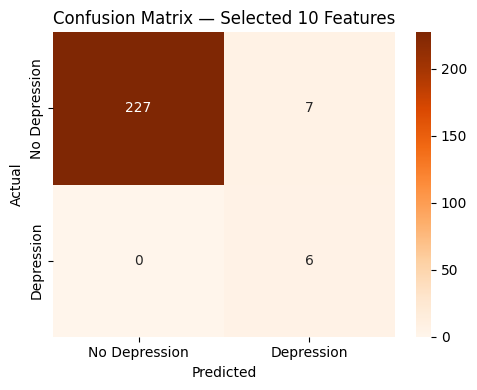

True Positives  (depressed correctly caught): 6
False Negatives (depressed cases missed):     0
False Positives (wrongly flagged):            7
True Negatives  (correctly cleared):          227


In [39]:
# =========================
# CONFUSION MATRIX
# (SELECTED 10 FEATURES)
# =========================

cm_sel = confusion_matrix(y_test_s, y_pred_s)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_sel, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Selected 10 Features")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_sel.ravel()
print(f"True Positives  (depressed correctly caught): {tp}")
print(f"False Negatives (depressed cases missed):     {fn}")
print(f"False Positives (wrongly flagged):            {fp}")
print(f"True Negatives  (correctly cleared):          {tn}")

Feature Importance (Selected 10 Features):

                 Feature  Importance
             sleep_hours    0.507016
            stress_level    0.327005
           anxiety_level    0.165640
screen_time_before_sleep    0.000340
daily_social_media_hours    0.000000
             gender_male    0.000000
         addiction_level    0.000000
    academic_performance    0.000000
       physical_activity    0.000000
                     age    0.000000


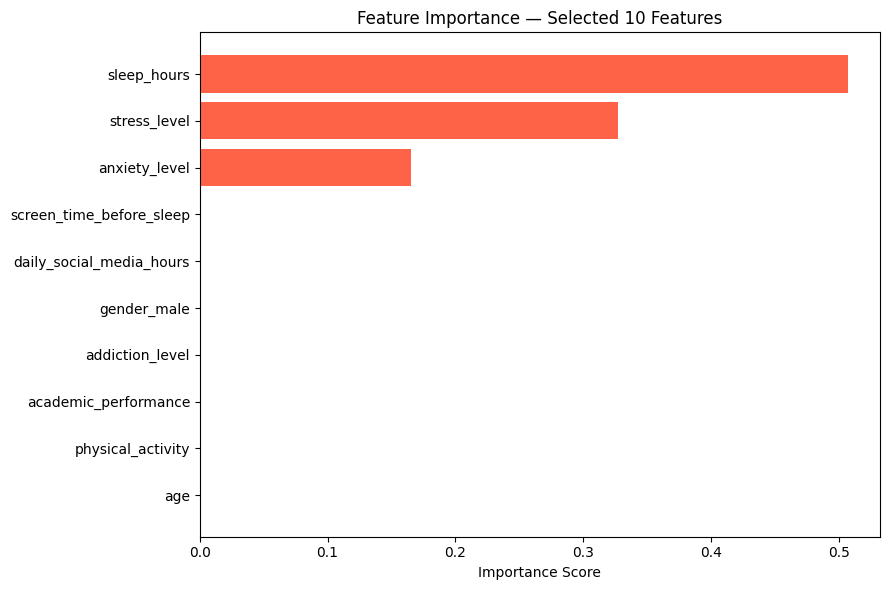

In [40]:
# =========================
# FEATURE IMPORTANCE
# (SELECTED 10 FEATURES)
# =========================

importance_sel = pd.DataFrame({
    'Feature'   : selected_features,
    'Importance': model_sel.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Selected 10 Features):\n")
print(importance_sel.to_string(index=False))

plt.figure(figsize=(9, 6))
plt.barh(importance_sel['Feature'], importance_sel['Importance'], color='tomato')
plt.xlabel("Importance Score")
plt.title("Feature Importance — Selected 10 Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

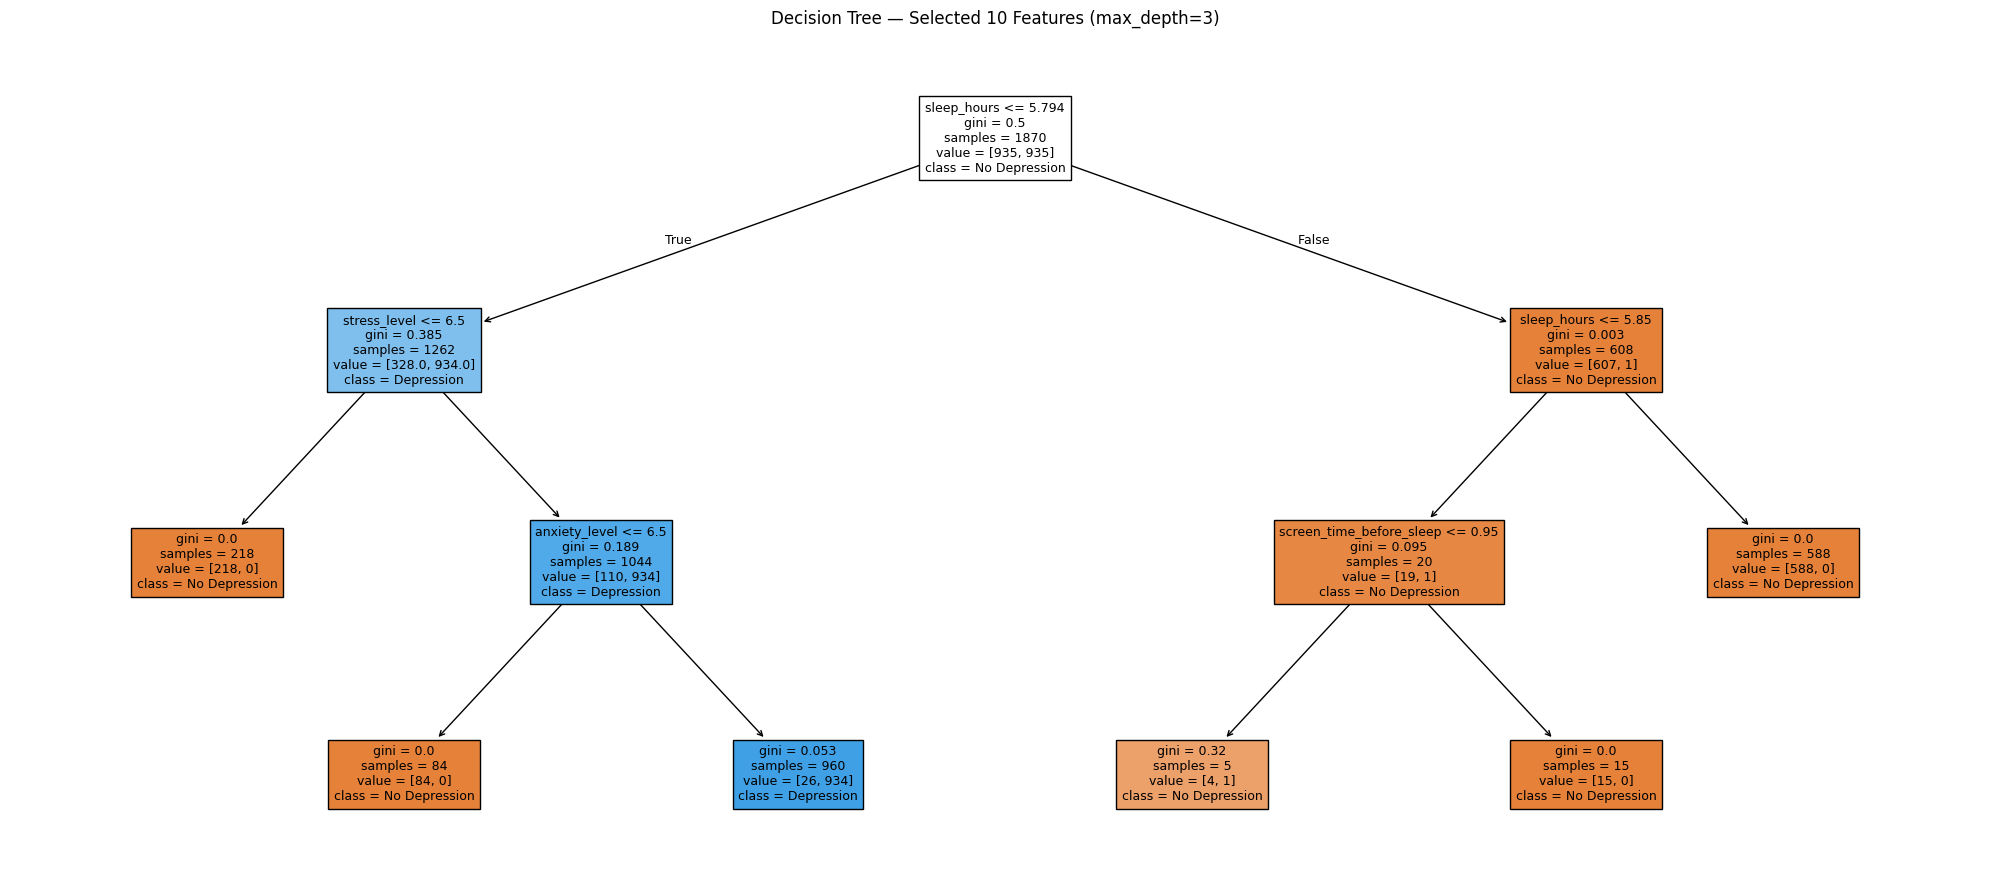

In [41]:
# =========================
# DECISION TREE VISUALISATION
# (SELECTED 10 FEATURES)
# =========================

plt.figure(figsize=(20, 9))
plot_tree(model_sel,
          feature_names=selected_features,
          class_names=['No Depression', 'Depression'],
          filled=True, fontsize=9)
plt.title("Decision Tree — Selected 10 Features (max_depth=3)")
plt.tight_layout()
plt.show()

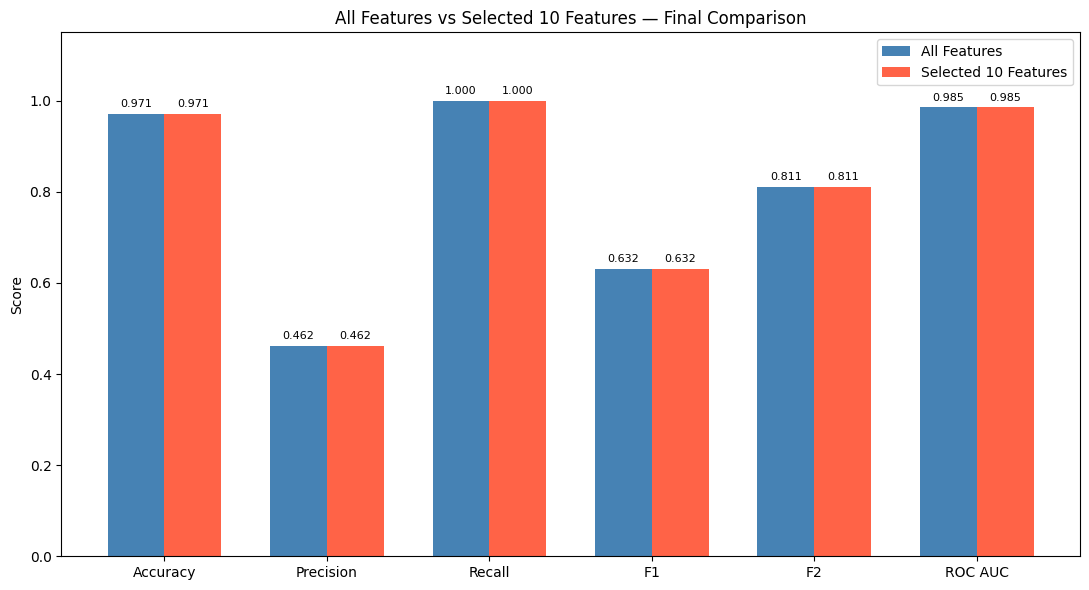


 SUMMARY: All Features vs Selected 10 Features
   Metric  All Features  Selected 10 Only  Difference
 Accuracy        0.9708            0.9708      0.0000
Precision        0.4615            0.4615      0.0000
   Recall        1.0000            1.0000      0.0000
       F1        0.6316            0.6316      0.0000
       F2        0.8108            0.8108      0.0000
  ROC AUC        0.9850            0.9850      0.0000

  F2 change     : +0.0000
  ROC AUC change: +0.0000

  ✅ Selected 10 features perform comparably to all features
     → Simpler model with fewer features is preferred


In [42]:
# =========================
# ALL FEATURES vs SELECTED 10 FEATURES
# FINAL COMPARISON
# =========================
import numpy as np

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'ROC AUC']
scores_all   = [accuracy,     precision,     recall,     f1,     f2,     roc_auc]
scores_sel   = [sel_accuracy, sel_precision, sel_recall, sel_f1, sel_f2, sel_roc_auc]

x, w = np.arange(len(metric_names)), 0.35

plt.figure(figsize=(11, 6))
bars1 = plt.bar(x - w/2, scores_all, w,
                label='All Features',        color='steelblue')
bars2 = plt.bar(x + w/2, scores_sel, w,
                label='Selected 10 Features', color='tomato')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.title("All Features vs Selected 10 Features — Final Comparison")
plt.ylim(0, 1.15)
plt.legend()
plt.tight_layout()
plt.show()

# --- Summary Table ---
summary = pd.DataFrame({
    'Metric'          : metric_names,
    'All Features'    : scores_all,
    'Selected 10 Only': scores_sel,
    'Difference'      : [s - a for s, a in zip(scores_sel, scores_all)]
})

print("\n" + "="*55)
print(" SUMMARY: All Features vs Selected 10 Features")
print("="*55)
print(summary.to_string(index=False, float_format="{:.4f}".format))

f2_diff  = sel_f2      - f2
auc_diff = sel_roc_auc - roc_auc

print(f"\n  F2 change     : {f2_diff:+.4f}")
print(f"  ROC AUC change: {auc_diff:+.4f}")

if f2_diff >= -0.02:
    print("\n  ✅ Selected 10 features perform comparably to all features")
    print("     → Simpler model with fewer features is preferred")
else:
    print("\n  ⚠️  Performance drops with selected 10 features")
    print("     → Full feature model is preferred")

## SGD

In [43]:
# === Feature Scaling ===
# Scale features to have zero mean and unit variance for better model performance.

from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test  = scaler.transform(X_test)

# X_train.shape, X_test.shape
from sklearn.linear_model import SGDClassifier

In [44]:
# === Threshold Search Utility ===
# Helpers to find the probability threshold that maximizes F2-score.

import numpy as np
from sklearn.metrics import fbeta_score, make_scorer, precision_score, recall_score, confusion_matrix

def find_best_threshold(proba, y_test, beta=2.0):

    thresholds = np.arange(0.001, 0.953, 0.001)

    best_t = None
    best_f2 = -1

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        f2 = fbeta_score(y_test, y_pred, beta=beta)

        if f2 > best_f2:
            best_f2 = f2
            best_t = t

    y_pred_best = (proba >= best_t).astype(int)
    cm = confusion_matrix(y_test, y_pred_best)

    return {
        "best_threshold": best_t,
        "y_pred": y_pred_best,
        "best_f2": best_f2,
        "precision": precision_score(y_test, y_pred_best),
        "recall": recall_score(y_test, y_pred_best),
        "confusion_matrix": cm
    }

In [45]:
# === Hyperparameter Tuning ===
# Grid search utilities and scoring helpers for model tuning.

from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, roc_curve, auc
)

def get_scores(classifier, X_test, y_test=y_test):
    X_test = X_test if X_test is not None else X_test
    proba = classifier.predict_proba(X_test)[:, 1]
    result = find_best_threshold(proba, y_test)
    y_pred = result['y_pred']
    f2 = result['best_f2']
    recall = result['recall']
    precision = result['precision']
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, proba)
    accuracy = accuracy_score(y_test, y_pred)
    print("F2:", f2, "\nRecall:", recall, "\nF1:", f1, "\nROC AUC:", roc_auc, "\nAccuracy:", accuracy, "\nPrecision:", precision)
    se = pd.Series([y_pred, proba, f2, recall, f1, accuracy, roc_auc, precision], index=['y_pred', 'proba', 'F2', 'Recall', 'F1', 'Accuracy', 'ROC AUC', 'Precision'])

    return se

def plot_confusion_matrix(title, y_pred, y_test=y_test):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Depressed', 'Depressed'], yticklabels=['Not Depressed', 'Depressed'])
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'{title} Confusion Matrix')
    plt.show()

# metrics = ['F2', 'Recall', 'F1', 'Accuracy', 'ROC AUC', 'Precision']
metrics = ['F2', 'Recall', 'ROC AUC', 'Precision']
def compare_multiple_scores(metrics, before_scores, after_scores_list, labels=None, title="Performance Comparison"):
    x = np.arange(len(metrics))
    width = 0.15  # each bar width
    
    plt.figure(figsize=(12,6))
    
    # baseline (Before)
    plt.bar(x - width, before_scores, width, label='SGD', color='skyblue')
    
    # models After
    for i, scores in enumerate(after_scores_list):
        offset = (i) * width
        plt.bar(x + offset, scores, width, label=labels[i] if labels else f'After {i+1}')
        # at each bar, show the value
        for j, v in enumerate(scores):
            plt.text(j + offset, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    # baseline value labels
    for j, v in enumerate(before_scores):
        plt.text(j - width, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    plt.xticks(x, metrics)
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_roc_curve(y_score, y_test=y_test):
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve'); plt.legend(); plt.show()

**Model Evaluation and Hyperparameter Tuning**

This section introduces the evaluation helpers, SMOTE + SGD baseline training, grid search tuning, and feature selection techniques for the teen mental health classification task.


In [46]:
# === Model Performance Evaluation Helper ===
# Compute training and testing performance metrics for a fitted classifier.
# The function also reports whether the model appears to be overfitting or underfitting.

def evaluate_fit(model, X_train, y_train, X_test, y_test, beta=2.0):
    # ---------- training set ----------
    proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_train = (proba_train >= 0.5).astype(int)

    train_f2 = fbeta_score(y_train, y_pred_train, beta=beta)
    train_recall = recall_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    train_auc = roc_auc_score(y_train, proba_train)

    # ---------- testing set ----------
    proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (proba_test >= 0.5).astype(int)

    test_f2 = fbeta_score(y_test, y_pred_test, beta=beta)
    test_recall = recall_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, proba_test)

    # ---------- model diagnosis ----------
    print("\n=== Model Diagnosis ===")

    # score gaps
    f2_gap = train_f2 - test_f2
    auc_gap = train_auc - test_auc

    # Overfitting
    if train_f2 > 0.8 and f2_gap > 0.15:
        print("⚠️ model Overfitting：training score is high but testing score is significantly lower")
    # Underfitting
    elif train_f2 < 0.6 and test_f2 < 0.6:
        print("⚠️ model Underfitting：training and testing scores are both low, model is not learning well")
    # normal
    else:
        print("✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting")

    return {
        "diagnosis": "overfit" if train_f2 > 0.8 and f2_gap > 0.15 else
                     "underfit" if train_f2 < 0.6 and test_f2 < 0.6 else
                     "good"
    }

After SMOTE training data distribution: Counter({0: 935, 1: 935})
F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9943019943019943 
Accuracy: 0.9833333333333333 
Precision: 0.6


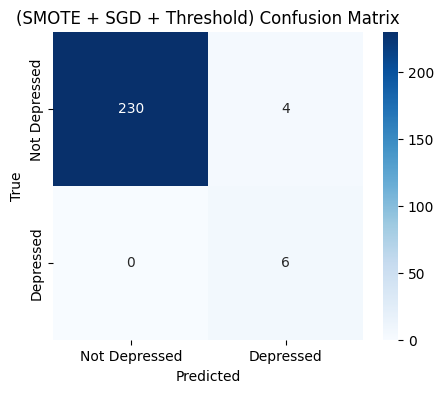


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [47]:
# === Train Baseline SGD Model with SMOTE ===
# Fit an imbalanced-learn pipeline on training data and evaluate the classifier on the test set.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)       
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline, clone
from collections import Counter

sgd_base = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42, max_iter=5000, verbose=0)

pipe_sgd = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', clone(sgd_base))
])
pipe_sgd.fit(X_train_scaled, y_train)

smote_step = pipe_sgd.named_steps['smote']
X_resampled, y_resampled = smote_step.fit_resample(X_train, y_train)
print("After SMOTE training data distribution:", Counter(y_resampled))

pipe_sgd_scores = get_scores(pipe_sgd, X_test_scaled)
plot_confusion_matrix('(SMOTE + SGD + Threshold)', pipe_sgd_scores['y_pred'])

evaluate_fit(pipe_sgd, X_train_scaled, y_train, X_test_scaled, y_test)


F2: 0.8571428571428571 
Recall: 1.0 
F1: 0.7058823529411764 
ROC AUC: 0.9935897435897435 
Accuracy: 0.9791666666666666 
Precision: 0.5454545454545454
F2: 0.8108108108108109 
Recall: 1.0 
F1: 0.631578947368421 
ROC AUC: 0.9928774928774928 
Accuracy: 0.9708333333333333 
Precision: 0.46153846153846156
F2: 0.8333333333333334 
Recall: 1.0 
F1: 0.6666666666666666 
ROC AUC: 0.9928774928774928 
Accuracy: 0.975 
Precision: 0.5
F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9943019943019943 
Accuracy: 0.9833333333333333 
Precision: 0.6
grid_1 ['clf__penalty', 'clf__alpha', 'clf__max_iter', 'smote__k_neighbors'] {'clf__alpha': 0.01, 'clf__max_iter': 1000, 'clf__penalty': 'l1', 'smote__k_neighbors': 5} F2=0.86
grid_2 ['clf__alpha', 'clf__max_iter', 'smote__k_neighbors'] {'clf__alpha': 0.01, 'clf__max_iter': 1000, 'smote__k_neighbors': 3} F2=0.81
grid_3 ['clf__max_iter', 'smote__k_neighbors'] {'clf__max_iter': 1000, 'smote__k_neighbors': 7} F2=0.83
grid_4 ['clf__max_iter'] 

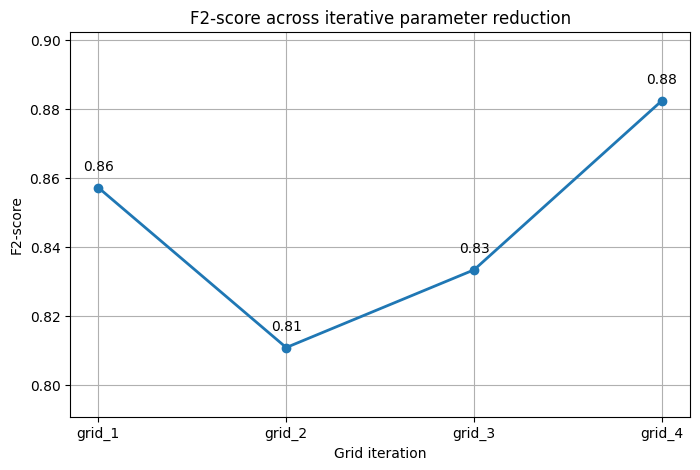

     grid                                   params        F2
0  grid_1  {penalty, alpha, max_iter, k_neighbors}  0.857143
1  grid_2           {alpha, max_iter, k_neighbors}  0.810811
2  grid_3                  {max_iter, k_neighbors}  0.833333
3  grid_4                               {max_iter}  0.882353


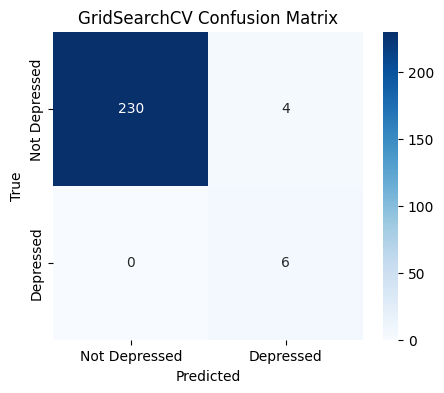

In [49]:
# === Iterative Grid Search with Shrinking Parameter Sets ===
# Perform multiple grid searches while progressively reducing the parameter search space.

import warnings
from pyparsing import results
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning
from sklearn.base import clone
import random

def build_shrinking_param_grid_list(base_param_grid, random_state=42):
    rng = random.Random(random_state)
    keys = list(base_param_grid.keys())
    current_keys = keys.copy()
    param_grid_list = []
    while current_keys:
        param_grid_list.append({k: base_param_grid[k] for k in current_keys})
        if len(current_keys) == 1:
            break
        remove_key = rng.choice(current_keys)
        current_keys.remove(remove_key)
    return param_grid_list

def run_param_grid_sequence(
    estimator, param_grid_list, X_train, y_train,
    cv, scoring, n_jobs=-1, verbose=0, refit=True
):
    results = []

    for i, params in enumerate(param_grid_list, start=1):
        grid = GridSearchCV(
            estimator=clone(estimator),
            param_grid=params,
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs,
            verbose=verbose,
            refit=refit,
        )
        grid.fit(X_train, y_train)
        grid_scores = get_scores(grid, X_test)

        results.append({
            "name": f"grid_{i}",
            "param_grid": params,
            "best_params": grid.best_params_,
            "best_score": grid_scores['F2'],
            "best_estimator": grid.best_estimator_,
            "cv_results": pd.DataFrame(grid.cv_results_),
            "grid_scores": grid_scores
        })

    return results

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=FitFailedWarning)

base_param_grid = {
    'clf__penalty': ['l2', 'l1', 'elasticnet'],
    'clf__alpha': [1e-4, 1e-3, 1e-2],
    'clf__max_iter': [1000, 3000, 5000],
    'smote__k_neighbors': [3, 5, 7]
}

param_grid_list = build_shrinking_param_grid_list(base_param_grid, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def f2_with_threshold_scorer(estimator, X, y):
    # 1. get predicted probabilities from the estimator
    proba = estimator.predict_proba(X)[:, 1]

    # 2. use find_best_threshold() to find the best threshold
    result = find_best_threshold(proba, y, beta=2.0)

    # 3. return the F2-score to GridSearchCV
    return result["best_f2"]


grid_results = run_param_grid_sequence(
    pipe_sgd,
    param_grid_list,
    X_train,
    y_train,
    cv,
    f2_with_threshold_scorer,
    n_jobs=-1,
    verbose=0,
)

for result in grid_results:
    print(result["name"], list(result["param_grid"].keys()), result["best_params"], f'F2={result["best_score"]:.2f}')

f2_scores_list = [result["best_score"] for result in grid_results]

grid_names = ["grid_1", "grid_2", "grid_3", "grid_4"]
f2_scores = [f2_scores_list[0], f2_scores_list[1], f2_scores_list[2], f2_scores_list[3]]

plt.figure(figsize=(8,5))
plt.plot(grid_names, f2_scores, marker='o', linewidth=2)

for i, score in enumerate(f2_scores):
    plt.text(i, score + 0.005, f"{score:.2f}", ha='center')

plt.title("F2-score across iterative parameter reduction")
plt.xlabel("Grid iteration")
plt.ylabel("F2-score")
plt.ylim(min(f2_scores)-0.02, max(f2_scores)+0.02)
plt.grid(True)
plt.show()

data = {
    "grid": ["grid_1", "grid_2", "grid_3", "grid_4"],
    "params": [
        "{penalty, alpha, max_iter, k_neighbors}",
        "{alpha, max_iter, k_neighbors}",
        "{max_iter, k_neighbors}",
        "{max_iter}"
    ],
    "F2": f2_scores_list
}

df = pd.DataFrame(data)
print(df)

plot_confusion_matrix('GridSearchCV', grid_results[3]['grid_scores']['y_pred'])

Best params: {'clf__penalty': 'l2'}
F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9943019943019943 
Accuracy: 0.9833333333333333 
Precision: 0.6


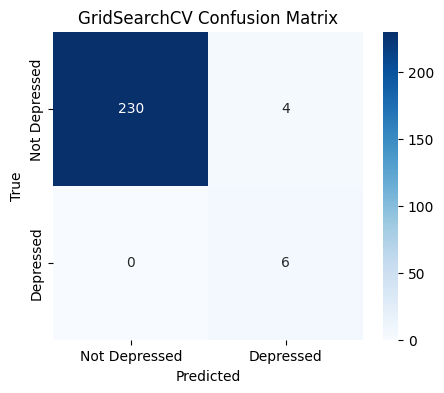

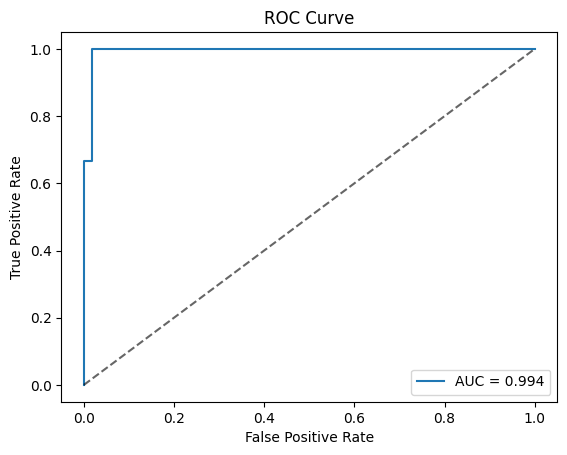


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [ ]:
# === Final Hyperparameter Tuning with GridSearchCV ===
# Run a refined grid search over the most promising parameters and evaluate the best estimator.

import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning
from sklearn.base import clone

def run_param_grid_sequence(
    estimator, param_grid_list, X_train, y_train,
    cv, scoring, n_jobs=-1, verbose=0, refit=True
):
    results = []

    for i, params in enumerate(param_grid_list, start=1):
        grid = GridSearchCV(
            estimator=clone(estimator),
            param_grid=params,
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs,
            verbose=verbose,
            refit=refit,
        )
        grid.fit(X_train, y_train)

        results.append({
            'name': f'grid_{i}',
            'param_grid': params,
            'best_params': grid.best_params_,
            'best_score': grid.best_score_,
            'best_estimator': grid.best_estimator_,
            'cv_results': pd.DataFrame(grid.cv_results_),
        })

    return results

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=FitFailedWarning)

param_grid = {
    'clf__penalty': ['l2', 'l1', 'elasticnet']
}

def f2_with_threshold_scorer(estimator, X, y):
    # 1. get predicted probabilities from the estimator
    proba = estimator.predict_proba(X)[:, 1]

    # 2. use find_best_threshold() to find the best threshold
    result = find_best_threshold(proba, y, beta=2.0)

    # 3. return the F2-score to GridSearchCV
    return result["best_f2"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #use stratified K-fold cross-validation to ensure consistent class distribution in each fold, leading to more reliable model evaluation results

grid = GridSearchCV(
    estimator=pipe_sgd,
    param_grid=param_grid,
    scoring=f2_with_threshold_scorer, #use F2 score as the evaluation metric, as it better balances precision and recall when dealing with imbalanced data
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train) #in the training data to perform grid search and find the best hyperparameter combination, thereby improving the model's performance and generalization ability

print("Best params:", grid.best_params_)

grid_model = grid.best_estimator_
gridSearchCV_Series = get_scores(grid_model, X_test)
plot_confusion_matrix('GridSearchCV', gridSearchCV_Series['y_pred'])

plot_roc_curve(grid_model.decision_function(X_test))

evaluate_fit(grid_model, X_train, y_train, X_test, y_test)

Best params: {'clf__alpha': 0.01, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'smote__k_neighbors': 3}
F2: 0.8064516129032258 
Recall: 0.8333333333333334 
F1: 0.7692307692307692 
ROC AUC: 0.9893162393162394 
Accuracy: 0.9875 
Precision: 0.7142857142857143


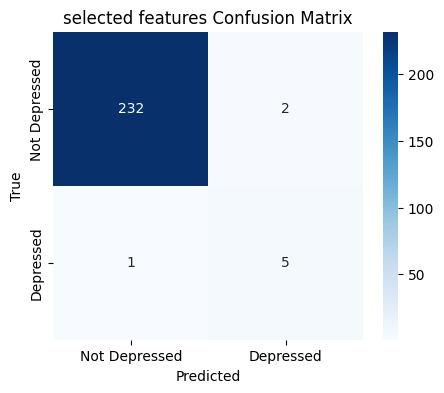

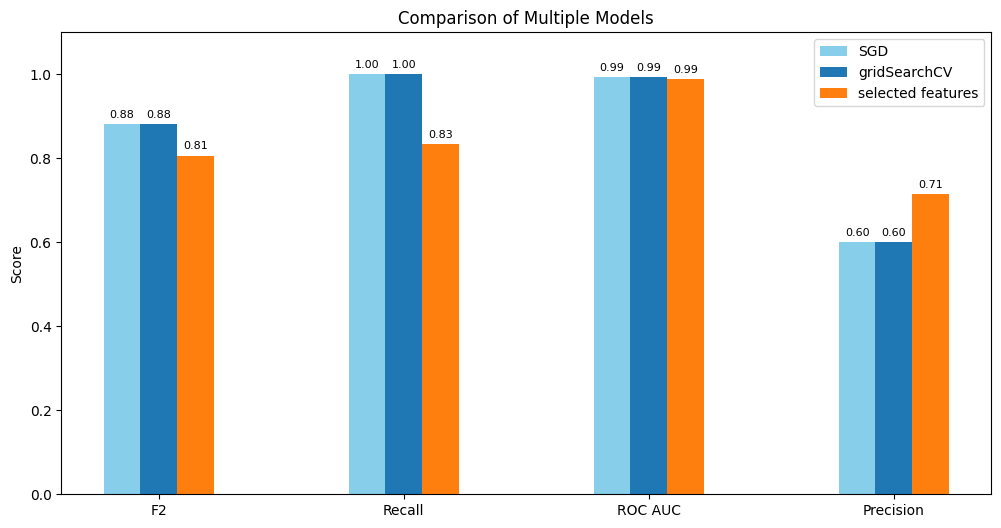

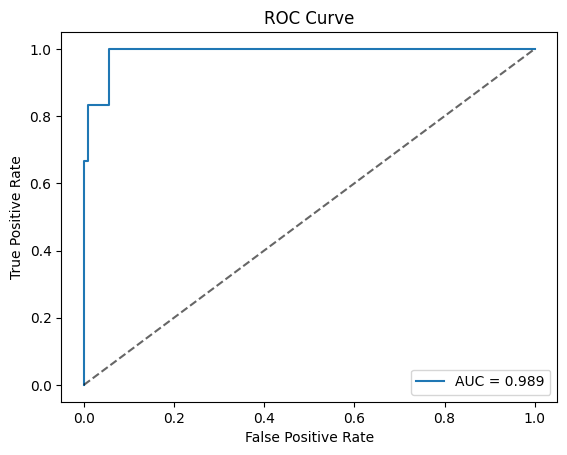


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [ ]:
# === Selected Feature Model Evaluation ===
# Train and evaluate the model using a selected subset of features to compare performance.

feature_names = X.columns
selected_features = ['sleep_hours', 'stress_level', 'anxiety_level', 'daily_social_media_hours', 'screen_time_before_sleep', 'gender', 'addiction_level']
mask = [f in selected_features for f in feature_names]
X_train_selected = X_train.loc[:, mask]

pipe_selected = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', clone(sgd_base))
])

param_grid = {
    'clf__penalty': ['l2', 'l1', 'elasticnet'],
    'clf__alpha': [1e-4, 1e-3, 1e-2],
    'clf__max_iter': [1000, 3000, 5000],
    'smote__k_neighbors': [3, 5, 7]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_selected,
    param_grid=param_grid,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_selected, y_train)

print("Best params:", grid.best_params_)

grid_model = grid.best_estimator_
selected_features_scores = get_scores(grid_model, X_test.loc[:, mask])
plot_confusion_matrix('selected features',selected_features_scores['y_pred'])

before = [pipe_sgd_scores['F2'], pipe_sgd_scores['Recall'], pipe_sgd_scores['ROC AUC'], pipe_sgd_scores['Precision']]

after_list = [
    [grid_results[3]['grid_scores']['F2'], grid_results[3]['grid_scores']['Recall'], grid_results[3]['grid_scores']['ROC AUC'], grid_results[3]['grid_scores']['Precision']],
    [selected_features_scores['F2'], selected_features_scores['Recall'], selected_features_scores['ROC AUC'], selected_features_scores['Precision']]
]

labels = ['gridSearchCV', 'selected features']

compare_multiple_scores(metrics, before, after_list, labels, title="Comparison of Multiple Models")

plot_roc_curve(grid_model.decision_function(X_test.loc[:, mask]))

evaluate_fit(grid_model, X_train_selected, y_train, X_test.loc[:, mask], y_test)


## Random Forest (Baseline)
Random Forest builds many decision trees and combines their results through voting, which is usually more accurate and more stable than a single decision tree. We use it as our baseline because:

Handles imbalanced data: just set class_weight='balanced'
No feature scaling needed: good for quick testing
Computes feature importance: useful for the later feature-removal experiment

=== Random Forest (Baseline) ===
Confusion matrix:
[[234   0]
 [  5   1]]

Accuracy               : 0.9792
Recall (positive class): 0.1667
F2     (positive class): 0.2000


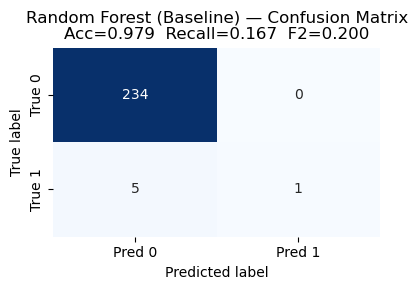

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, fbeta_score

# Baseline Random Forest — default hyperparameters, balanced class weights
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)
rf_base.fit(X_train, y_train)

#Predictions on the held-out test set
y_pred = rf_base.predict(X_test)

# Metrics
cm       = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
recall   = recall_score(y_test, y_pred)
f2       = fbeta_score(y_test, y_pred, beta=2)

#===============print===================================================
print("=== Random Forest (Baseline) ===")
print("Confusion matrix:")
print(cm)
print(f"\nAccuracy               : {accuracy:.4f}")
print(f"Recall (positive class): {recall:.4f}")
print(f"F2     (positive class): {f2:.4f}")

# Plot confusion matrix as a heatmap
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['True 0', 'True 1'],
    ax=ax,
)
ax.set_title(
    f'Random Forest (Baseline) — Confusion Matrix\n'
    f'Acc={accuracy:.3f}  Recall={recall:.3f}  F2={f2:.3f}'
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()


**Train a Random Forest with SMOTE oversampling to handle the class imbalance, then evaluate on the test set and visualize the confusion matrix.**



=== Random Forest + SMOTE ===
Confusion matrix:
[[234   0]
 [  3   3]]

Accuracy               : 0.9875
Recall (positive class): 0.5000
F2     (positive class): 0.5556


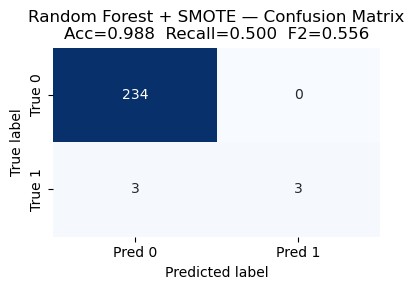

In [ ]:
# ─── Imports ────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE                                      
from imblearn.pipeline import Pipeline as ImbPipeline                        
from sklearn.ensemble import RandomForestClassifier                           
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, fbeta_score  
import matplotlib.pyplot as plt                                              
import seaborn as sns                                                        


# ─── Build the SMOTE + Random Forest pipeline ───────────────────────────────
# SMOTE oversamples the minority class inside training folds only, then Random Forest classifies — no leakage into validation.
pipe_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),                                        # Step 1: oversample minority class (seed fixed for reproducibility)
    ('clf',   RandomForestClassifier(random_state=42, n_jobs=-1)),            # Step 2: train Random Forest in parallel using all CPU cores
])


# ─── Train and predict ──────────────────────────────────────────────────────
pipe_rf.fit(X_train, y_train)                                                 # Fit the pipeline: apply SMOTE to training data, then train Random Forest
y_pred_smote = pipe_rf.predict(X_test)                                        # Predict on the test set (SMOTE is skipped at inference time)


# ─── Compute evaluation metrics ─────────────────────────────────────────────
cm_s       = confusion_matrix(y_test, y_pred_smote)                           # 2x2 confusion matrix: TN/FP/FN/TP
accuracy_s = accuracy_score(y_test, y_pred_smote)                             # Overall correctness across all samples
recall_s   = recall_score(y_test, y_pred_smote)                               # % of true positives the model caught
f2_s       = fbeta_score(y_test, y_pred_smote, beta=2)                        # F2 score — weights recall 2x more than precision


# ─── Print results to console ───────────────────────────────────────────────
print("=== Random Forest + SMOTE ===")                                        
print("Confusion matrix:")                                                    
print(cm_s)                                                                   
print(f"\nAccuracy               : {accuracy_s:.4f}")                         
print(f"Recall (positive class): {recall_s:.4f}")                             
print(f"F2     (positive class): {f2_s:.4f}")                                 


# ─── Visualize the confusion matrix as a heatmap ────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3))                                        
sns.heatmap(                                                                  
    cm_s, annot=True, fmt='d', cmap='Blues', cbar=False,                      # Show integer counts in blue cells, no color bar
    xticklabels=['Pred 0', 'Pred 1'],                                         # X-axis labels = predicted class
    yticklabels=['True 0', 'True 1'],                                         # Y-axis labels = true class
    ax=ax,                                                                    # Draw onto the axis we created
)

ax.set_title(                                                                 # Title combining model name and key metrics
    f'Random Forest + SMOTE — Confusion Matrix\n'
    f'Acc={accuracy_s:.3f}  Recall={recall_s:.3f}  F2={f2_s:.3f}'
)
ax.set_xlabel('Predicted label')                                              # X-axis title
ax.set_ylabel('True label')                                                   # Y-axis title
plt.tight_layout()                                                            # Auto-adjust spacing so labels are not cut off
plt.show()                                                                    # Render the figure


**Random Forest — GridSearchCV tuning**

We tune Random Forest with 5-fold **stratified** cross-validation, scoring on **ROC-AUC** (threshold-independent and robust to class imbalance). The grid covers tree count, depth, split/leaf size, and feature subsampling — a total of 48 combinations.

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
  (Train) CV Accuracy: 0.9885
  (Train) CV Recall  : 0.5600
  (Train) CV F2      : 0.6023

=== Random Forest + SMOTE + GridSearchCV (Test Set) ===
Confusion matrix:
[[234   0]
 [  3   3]]

Test Accuracy: 0.9875
Test Recall  : 0.5000
Test F2      : 0.5556


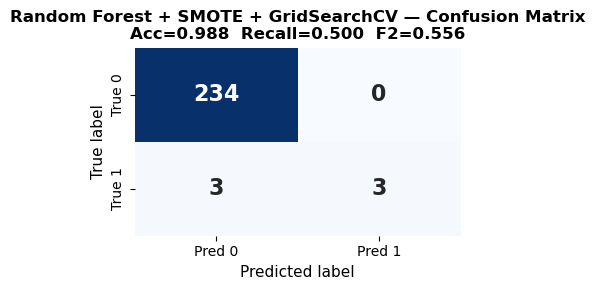

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold             
from sklearn.metrics import make_scorer, fbeta_score, confusion_matrix, accuracy_score, recall_score  
from imblearn.over_sampling import SMOTE                                       
from imblearn.pipeline import Pipeline as ImbPipeline                         
from sklearn.ensemble import RandomForestClassifier                            
import matplotlib.pyplot as plt                                              
import seaborn as sns                                                        


# ─── Build the SMOTE + Random Forest pipeline ───────────────────────────────
# SMOTE runs only inside training folds during CV, preventing leakage into validation.
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),                                         # Step 1: oversample minority class (seed fixed for reproducibility)
    ('clf',   RandomForestClassifier(random_state=42, n_jobs=-1)),             # Step 2: train Random Forest in parallel using all CPU cores
])


# ─── Define the hyperparameter grid ─────────────────────────────────────────
# 2 × 3 × 2 × 2 × 2 = 48 combinations; 'clf__' prefix targets the RF step inside the pipeline.
rf_param_grid = {
    'clf__n_estimators':      [100, 300],                                      # Number of trees in the forest
    'clf__max_depth':         [None, 10, 20],                                  # Max depth of each tree (None = unlimited)
    'clf__min_samples_split': [2, 5],                                          # Min samples required to split an internal node
    'clf__min_samples_leaf':  [1, 2],                                          # Min samples required at a leaf node
    'clf__max_features':      ['sqrt', 'log2'],                                # Feature subset size considered at each split
}


# ─── Configure cross-validation and the F2 scorer ───────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)                # 5-fold stratified CV preserves class balance per fold
f2_scorer = make_scorer(fbeta_score, beta=2)                                   # Custom F2 scorer (recall weighted 2x more than precision)


# ─── Run GridSearchCV to find the best hyperparameters ──────────────────────
rf_grid = GridSearchCV(
    estimator=pipe,                                                           
    param_grid=rf_param_grid,                                                  # 48 combinations defined above
    scoring={'accuracy': 'accuracy', 'recall': 'recall', 'f2': f2_scorer},     # Track 3 metrics during CV
    refit='f2',                                                                # Refit the best model on the full training set using F2 as the criterion
    cv=cv,                                                                     # Use the stratified 5-fold splitter
    n_jobs=-1,                                                                 # Parallelize across all CPU cores
    verbose=1,                                                                 # Print progress while searching
)

rf_grid.fit(X_train, y_train)                                                  # Run the full grid search on training data


# ─── Report the best hyperparameters and CV scores ──────────────────────────
best_idx   = rf_grid.best_index_                                               # Index of the winning combination in cv_results_
cv_results = rf_grid.cv_results_                                               # Full CV results table

print(f"Best params: {rf_grid.best_params_}")                                 
print(f"  (Train) CV Accuracy: {cv_results['mean_test_accuracy'][best_idx]:.4f}")  
print(f"  (Train) CV Recall  : {cv_results['mean_test_recall'][best_idx]:.4f}")    
print(f"  (Train) CV F2      : {cv_results['mean_test_f2'][best_idx]:.4f}")       


# ─── Evaluate the best model on the held-out test set ───────────────────────
y_pred_grid = rf_grid.predict(X_test)                                          # Predict using the refit best estimator

cm_g       = confusion_matrix(y_test, y_pred_grid)                             # 2x2 confusion matrix: TN/FP/FN/TP
accuracy_g = accuracy_score(y_test, y_pred_grid)                               # Overall correctness on test set
recall_g   = recall_score(y_test, y_pred_grid)                                 # % of true positives caught
f2_g       = fbeta_score(y_test, y_pred_grid, beta=2)                          # F2 score — our main screening metric


# ─── Print test-set results ─────────────────────────────────────────────────
print("\n=== Random Forest + SMOTE + GridSearchCV (Test Set) ===")            
print("Confusion matrix:")                                                    
print(cm_g)                                                                    
print(f"\nTest Accuracy: {accuracy_g:.4f}")                                   
print(f"Test Recall  : {recall_g:.4f}")                                        
print(f"Test F2      : {f2_g:.4f}")                                          


# ─── Visualize the confusion matrix as a heatmap ────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3))                                         # Create a 4x3 inch figure with one axis
sns.heatmap(                                                                  
    cm_g, annot=True, fmt='d', cmap='Blues', cbar=False,                       # Show integer counts in blue cells, no color bar
    xticklabels=['Pred 0', 'Pred 1'],                                          # X-axis labels = predicted class
    yticklabels=['True 0', 'True 1'],                                          # Y-axis labels = true class
    annot_kws={'size': 16, 'fontweight': 'bold'},                              # Make in-cell numbers large and bold
    ax=ax,                                                                     # Draw onto the axis we created
)
ax.set_title(                                                                  # Title combining model name and key metrics
    f'Random Forest + SMOTE + GridSearchCV — Confusion Matrix\n'                
    f'Acc={accuracy_g:.3f}  Recall={recall_g:.3f}  F2={f2_g:.3f}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Predicted label', fontsize=11)                                  # X-axis title
ax.set_ylabel('True label', fontsize=11)                                       # Y-axis title
plt.tight_layout()                                                             # Auto-adjust spacing so labels are not cut off
plt.show()                                                                   


CV threshold scan (training set):
 threshold  accuracy  recall     f2
    0.0100    0.5781  1.0000 0.2358
    0.0200    0.7292  1.0000 0.3247
    0.0300    0.7937  1.0000 0.3870
    0.0400    0.8354  1.0000 0.4417
    0.0500    0.8604  1.0000 0.4826
    0.0600    0.8823  1.0000 0.5252
    0.0700    0.8969  1.0000 0.5580
    0.0800    0.9052  1.0000 0.5787
    0.0900    0.9146  1.0000 0.6039
    0.1000    0.9323  1.0000 0.6579
    0.1100    0.9417  0.9600 0.6704
    0.1200    0.9521  0.9600 0.7101
    0.1300    0.9677  0.9600 0.7792
    0.1400    0.9771  0.9600 0.8276
    0.1500    0.9802  0.9600 0.8451
    0.1600    0.9833  0.9600 0.8633
    0.1700    0.9906  0.9600 0.9091
    0.1800    0.9927  0.9600 0.9231
    0.1900    0.9958  0.9600 0.9449
    0.2000    0.9969  0.9600 0.9524
    0.2100    0.9969  0.9600 0.9524
    0.2200    0.9969  0.9600 0.9524
    0.2300    0.9979  0.9600 0.9600
    0.2400    0.9979  0.9200 0.9350
    0.2500    0.9979  0.9200 0.9350
    0.2600    0.9979  0.9200 0

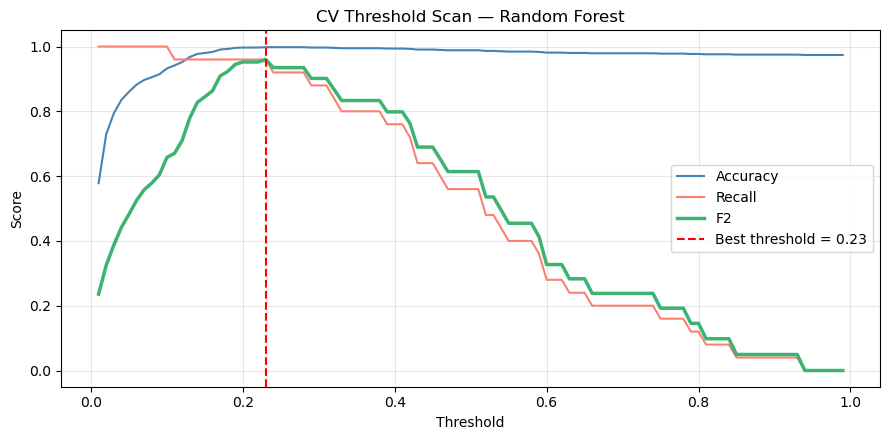


[Honest test set @ threshold=0.230]
  Test Accuracy : 1.0000
  Test Recall   : 1.0000
  Test F2       : 1.0000
Confusion matrix:
[[234   0]
 [  0   6]]


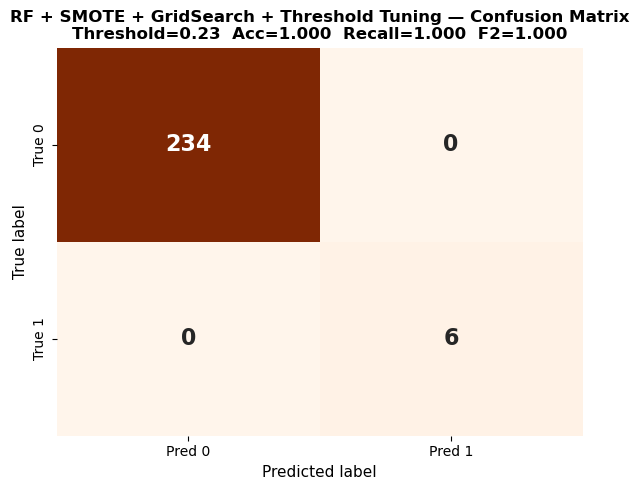

In [ ]:
import numpy as np                                                          
import pandas as pd                                                           
import matplotlib.pyplot as plt                                               
import seaborn as sns                                                         
from sklearn.model_selection import cross_val_predict                          
from sklearn.metrics import accuracy_score, recall_score, fbeta_score, confusion_matrix  


# ─── Get the best estimator from the previous GridSearchCV step ─────────────
rf_best = rf_grid.best_estimator_                                              # The refit pipeline (SMOTE + tuned RandomForest)


# ─── Generate leakage-free probabilities via 5-fold CV ──────────────────────
# cross_val_predict refits the model on each fold and predicts on its held-out fold —

y_proba_cv = cross_val_predict(
    rf_best, X_train, y_train,                                                 # Use only training data — never touch X_test here
    cv=5, method='predict_proba'                                               # 5-fold CV, return class probabilities
)[:, 1]                                                                        # Keep column 1 only (probability of class 1 = depressed)


# ─── Scan thresholds from 0.01 to 0.99 and record metrics at each ───────────
thresholds = np.arange(0.01, 1.00, 0.01)                                       # 99 candidate thresholds in steps of 0.01
records = []                                                                   # Collect per-threshold metrics here
for t in thresholds:                                                           # Loop over each candidate threshold
    y_pred_cv = (y_proba_cv >= t).astype(int)                                  # Convert probabilities to 0/1 using threshold t
    records.append({                                                           # Record metrics at this threshold
        'threshold': t,
        'accuracy':  accuracy_score(y_train, y_pred_cv),                       # Overall correctness
        'recall':    recall_score(y_train, y_pred_cv, zero_division=0),        # % of true positives caught (0 if no positives predicted)
        'f2':        fbeta_score(y_train, y_pred_cv, beta=2, zero_division=0), # F2 — recall-weighted, our main metric
    })

scan_df = pd.DataFrame(records)                                                # Convert list of dicts to a DataFrame for easy analysis


# ─── Pick the threshold that maximizes F2 ───────────────────────────────────
best_idx          = scan_df['f2'].idxmax()                                     # Row index of the highest F2
best_threshold_cv = scan_df.loc[best_idx, 'threshold']                         # Threshold value at that row — the winner


# ─── Print the threshold scan and the chosen threshold ──────────────────────
print('CV threshold scan (training set):')                                     
print(scan_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))       # Print full scan table with 4-decimal formatting

print(f"\n[CV-based, picked by max F2]")                                      
print(f"  Threshold   : {best_threshold_cv:.3f}")                            
print(f"  CV Accuracy : {scan_df.loc[best_idx, 'accuracy']:.4f}")            
print(f"  CV Recall   : {scan_df.loc[best_idx, 'recall']:.4f}")              
print(f"  CV F2       : {scan_df.loc[best_idx, 'f2']:.4f}")                   


# ─── Plot the metric curves vs threshold ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))                                       # Create a 9x4.5 inch figure with one axis
ax.plot(scan_df['threshold'], scan_df['accuracy'], label='Accuracy', color='steelblue')        # Accuracy curve (blue)
ax.plot(scan_df['threshold'], scan_df['recall'],   label='Recall',   color='salmon')           # Recall curve (salmon)
ax.plot(scan_df['threshold'], scan_df['f2'],       label='F2',       color='mediumseagreen', linewidth=2.5)  # F2 curve (green, thicker — main metric)
ax.axvline(best_threshold_cv, color='red', linestyle='--', label=f'Best threshold = {best_threshold_cv:.2f}')  # Vertical line at chosen threshold
ax.set_xlabel('Threshold')                                                    
ax.set_ylabel('Score')                                                        
ax.set_title('CV Threshold Scan — Random Forest')                             
ax.legend()                                                                    # Show legend with all curve labels
ax.grid(alpha=0.3)                                                             # Light grid to make values easier to read
plt.tight_layout()                                                             # Auto-adjust spacing so labels are not cut off
plt.show()                                                                   


# ─── Apply the CV-chosen threshold to the test set (honest evaluation) ──────
y_proba_test  = rf_best.predict_proba(X_test)[:, 1]                            # Predict probabilities on the held-out test set
y_pred_honest = (y_proba_test >= best_threshold_cv).astype(int)                # Convert to 0/1 using the threshold we picked via CV


# ─── Compute test-set metrics ───────────────────────────────────────────────
acc_h    = accuracy_score(y_test, y_pred_honest)                               # Test accuracy
recall_h = recall_score(y_test, y_pred_honest)                                 # Test recall — % of true depressed cases caught
f2_h     = fbeta_score(y_test, y_pred_honest, beta=2)                          # Test F2 — our honest final score
cm_h     = confusion_matrix(y_test, y_pred_honest)                             # 2x2 confusion matrix on test set


# ─── Print test-set results ─────────────────────────────────────────────────
print(f"\n[Honest test set @ threshold={best_threshold_cv:.3f}]")              
print(f"  Test Accuracy : {acc_h:.4f}")                                       
print(f"  Test Recall   : {recall_h:.4f}")                                    
print(f"  Test F2       : {f2_h:.4f}")                                        
print("Confusion matrix:")                                                    
print(cm_h)                                                                   


# ─── Visualize the confusion matrix as a heatmap ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))                                         # Create a 6x5 inch figure with one axis
sns.heatmap(                                                                  
    cm_h, annot=True, fmt='d', cmap='Oranges', cbar=False,                     # Show integer counts in orange cells, no color bar (orange = threshold-tuned stage)
    xticklabels=['Pred 0', 'Pred 1'],                                          # X-axis labels = predicted class
    yticklabels=['True 0', 'True 1'],                                          # Y-axis labels = true class
    annot_kws={'size': 16, 'fontweight': 'bold'},                              # Make in-cell numbers large and bold
    ax=ax,                                                                     # Draw onto the axis we created
)
ax.set_title(                                                                  # Multi-line title with model name, threshold, and key metrics
    f'RF + SMOTE + GridSearch + Threshold Tuning — Confusion Matrix\n'
    f'Threshold={best_threshold_cv:.2f}  Acc={acc_h:.3f}  Recall={recall_h:.3f}  F2={f2_h:.3f}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Predicted label', fontsize=11)                                  # X-axis title
ax.set_ylabel('True label', fontsize=11)                                       # Y-axis title
plt.tight_layout()                                                             # Auto-adjust spacing so labels are not cut off
plt.show()                                                                     # Render the figure


In [ ]:
import numpy as np                                                            
import pandas as pd                                                           
import matplotlib.pyplot as plt                                               
from sklearn.model_selection import StratifiedKFold, train_test_split          
from sklearn.preprocessing import StandardScaler                              
from sklearn.ensemble import RandomForestClassifier                           
from sklearn.metrics import accuracy_score, recall_score, fbeta_score         


# ─── Reuse the F2-optimal threshold found in the previous threshold-tuning step ──
THRESHOLD = best_threshold_cv                                                  # Use the threshold (e.g. 0.23) we picked earlier


# ─── Prepare full feature set and split into train/test ─────────────────────
X_full = pd.get_dummies(df.drop(columns=['depression_label']), drop_first=True, dtype=int)  # One-hot encode categoricals; drop the target column
y_full = df['depression_label']                                                # Target = depression label (0/1)
feature_names = X_full.columns.tolist()                                        # List of all 14 feature names — used for the drop-one-out loop

X_train_raw, X_test_raw, y_train_cv, y_test_cv = train_test_split(             # Fresh split (independent of earlier X_train/X_test)
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full            # 80/20 split, stratified to preserve class balance
)


# ─── Configure 5-fold stratified CV ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)                # 5 folds, shuffled, seed fixed for reproducibility


# ─── Helper: run 5-fold CV with given features, return mean Accuracy/Recall/F2 ──
def cv_metrics(X, y, threshold):
    accs, recalls, f2s = [], [], []                                            # Collect per-fold metrics here
    for tr_idx, val_idx in cv.split(X, y):                                     # Loop over 5 (train_idx, val_idx) pairs
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]                          # Slice train and validation features
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]                          # Slice train and validation labels

        scaler = StandardScaler()                                              # Fresh scaler per fold to avoid leakage
        X_tr_s  = scaler.fit_transform(X_tr)                                   # Fit + transform on training fold
        X_val_s = scaler.transform(X_val)                                      # Transform validation fold using train statistics

        model = RandomForestClassifier(                                        # Build a fresh RF each fold
            **{k.replace('clf__', ''): v for k, v in rf_grid.best_params_.items()},  # Reuse GridSearchCV best hyperparameters (strip 'clf__' prefix)
            random_state=42, class_weight='balanced', n_jobs=-1,               # Fixed seed + balanced weights (faster than SMOTE for many runs)
        )
        model.fit(X_tr_s, y_tr)                                                # Train on this fold
        y_proba = model.predict_proba(X_val_s)[:, 1]                           # Probability of class 1 on validation fold
        y_pred  = (y_proba >= threshold).astype(int)                           # Apply threshold to get 0/1 predictions

        accs.append(accuracy_score(y_val, y_pred))                             # Record accuracy for this fold
        recalls.append(recall_score(y_val, y_pred, zero_division=0))           # Record recall (0 if no positives predicted)
        f2s.append(fbeta_score(y_val, y_pred, beta=2, zero_division=0))        # Record F2 (recall-weighted)

    return np.mean(accs), np.mean(recalls), np.mean(f2s)                       # Return the mean across 5 folds


# ─── Reference: CV score with all 14 features (the comparison baseline) ─────
a_ref, r_ref, f2_ref = cv_metrics(X_train_raw, y_train_cv, THRESHOLD)          # Full feature set CV score
reference = {'accuracy': a_ref, 'recall': r_ref, 'f2': f2_ref}                 # Store as dict for later plotting
print(f"Reference CV (all 14 features, threshold={THRESHOLD:.2f}) -> "        
      f"Acc={a_ref:.4f}, Recall={r_ref:.4f}, F2={f2_ref:.4f}\n")


# ─── Drop-one-out experiment: remove each feature and measure impact ────────
results = []                                                                   # Collect per-feature results here
for drop_feature in feature_names:                                             # Loop over each of the 14 features
    keep = [c for c in feature_names if c != drop_feature]                     # Keep all features except the one we're testing
    X_reduced = X_train_raw[keep]                                              # Subset the training data to the 13 kept features
    a, r, f2 = cv_metrics(X_reduced, y_train_cv, THRESHOLD)                    # Re-run 5-fold CV with that one feature missing
    results.append({'dropped_feature': drop_feature, 'accuracy': a, 'recall': r, 'f2': f2})  # Record the result

result_df = pd.DataFrame(results).sort_values('f2', ascending=True).reset_index(drop=True)   # Sort ascending — worst F2 first = most important features


# ─── Print the sorted results table ─────────────────────────────────────────
print(f'CV drop-feature results at threshold={THRESHOLD:.2f} (sorted by F2 ascending):')   
print(result_df.to_string(index=False))                                     


Reference CV (all 14 features, threshold=0.23) -> Acc=0.9969, Recall=0.9200, F2=0.9256

CV drop-feature results at threshold=0.23 (sorted by F2 ascending):
                dropped_feature  accuracy  recall       f2
                    sleep_hours  0.941667    0.64 0.483965
                   stress_level  0.958333    0.60 0.511473
                  anxiety_level  0.967708    0.76 0.648421
       daily_social_media_hours  0.973958    0.92 0.787567
       screen_time_before_sleep  0.994792    0.92 0.911282
           academic_performance  0.996875    0.92 0.925641
              physical_activity  0.996875    0.92 0.925641
                    gender_male  0.996875    0.92 0.925641
social_interaction_level_medium  0.996875    0.92 0.925641
                            age  0.997917    0.92 0.933333
                addiction_level  0.997917    0.92 0.933333
       platform_usage_Instagram  0.997917    0.92 0.933333
          platform_usage_TikTok  0.997917    0.92 0.933333
   social_interact

**Data visualization**

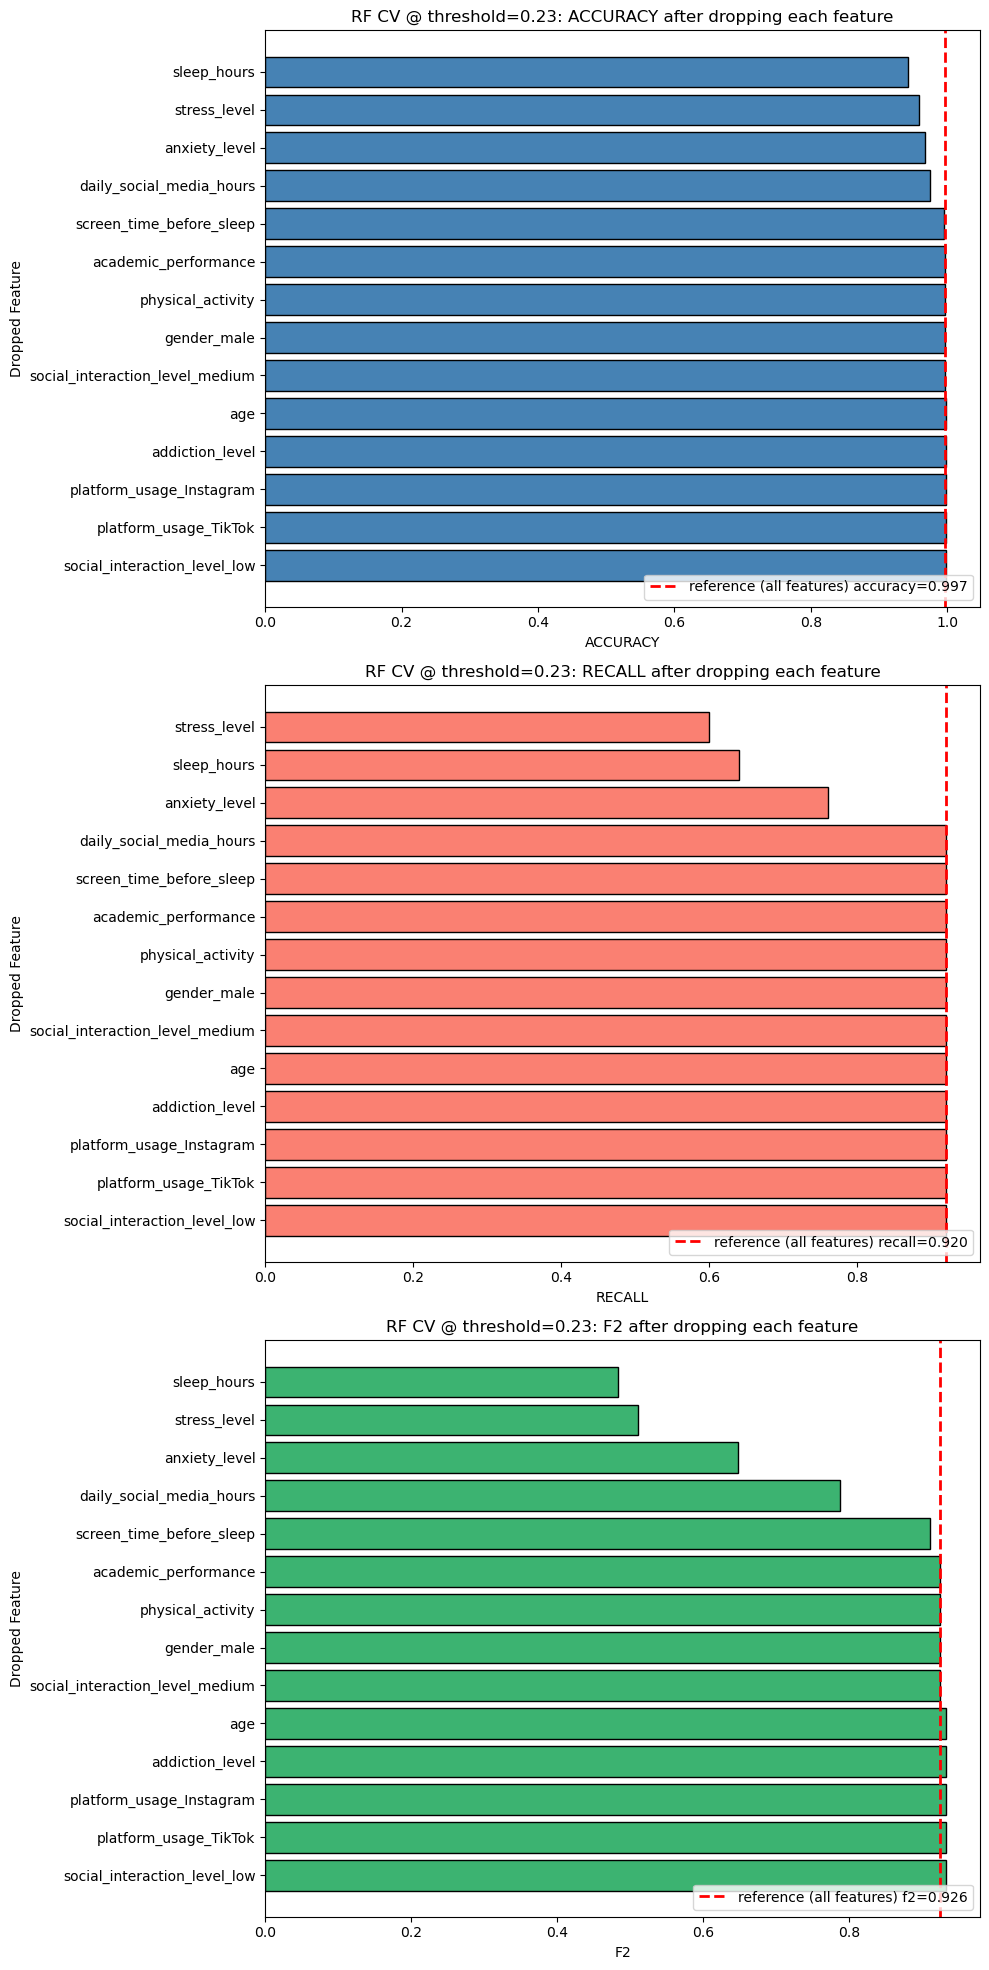

In [ ]:
# ─── Imports ────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt                                                # Plotting


# ─── Create a vertical stack of 3 subplots (one per metric) ─────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, len(result_df) * 0.4 * 3 + 3))     # 3 rows x 1 col; height scales with feature count


# ─── Loop over the 3 metrics and draw a horizontal bar chart for each ──────
for ax, metric, color in zip(                                                  # Pair each axis with its metric and bar color
    axes,                                                                      # The 3 subplot axes
    ['accuracy', 'recall', 'f2'],                                              # The 3 metrics to plot
    ['steelblue', 'salmon', 'mediumseagreen'],                                 # The 3 colors (consistent across the notebook)
):
    df_sorted = result_df.sort_values(metric, ascending=True)                  # Sort features by this metric (worst at top after invert)
    ax.barh(df_sorted['dropped_feature'], df_sorted[metric], color=color, edgecolor='black')  # Horizontal bars: feature name vs metric value
    ax.axvline(reference[metric], color='red', linestyle='--', linewidth=2,    # Red dashed line at the reference (all features) score
               label=f"reference (all features) {metric}={reference[metric]:.3f}")
    ax.set_xlabel(metric.upper())                                             
    ax.set_ylabel('Dropped Feature')                                        
    ax.set_title(f'RF CV @ threshold={THRESHOLD:.2f}: {metric.upper()} after dropping each feature')  
    ax.legend(loc='lower right')                                               # Show legend (with reference line value) in bottom-right
    ax.invert_yaxis()                                                          # Flip so the most-important feature (lowest metric) appears at top

plt.tight_layout()                                                             # Auto-adjust spacing so titles/labels don't overlap
plt.show()                                                                   


In [ ]:
# Drop a fixed set of features at once
drop_set = [ 'social_interaction_level_low', 'social_interaction_level_medium', 'platform_usage_Instagram', 'platform_usage_TikTok']
keep = [c for c in feature_names if c not in drop_set]
X_reduced = X_train_raw[keep]

a, r, f2 = cv_metrics(X_reduced, y_train_cv, THRESHOLD)
print(f"Drop {drop_set}")
print(f"  Accuracy={a:.4f}, Recall={r:.4f}, F2={f2:.4f}")
print(f"  vs Baseline: Acc={baseline['accuracy']:.4f}, Recall={baseline['recall']:.4f}, F2={baseline['f2']:.4f}")


Drop ['social_interaction_level_low', 'social_interaction_level_medium', 'platform_usage_Instagram', 'platform_usage_TikTok']
  Accuracy=0.9979, Recall=0.9200, F2=0.9333
  vs Baseline: Acc=0.9969, Recall=0.9200, F2=0.9256


═══ FINAL MODEL — Test Set Evaluation ═══
Features used   : 13 (dropped 4)
Threshold       : 0.23
Test Accuracy   : 1.0000
Test Recall     : 1.0000
Test F2         : 1.0000
Confusion matrix:
[[234   0]
 [  0   6]]


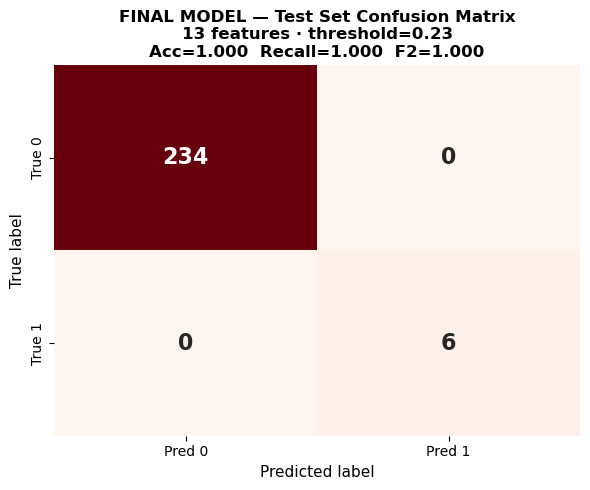

In [ ]:
# ─── Imports ────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt                                            
import seaborn as sns                                                         
from sklearn.metrics import confusion_matrix                                  


# ─── Final honest evaluation on test set ────────────────────────────────────
# All selections are now frozen:
# Hyperparameters: from GridSearchCV
# Threshold:       0.23 (from threshold tuning)
# Features:        all minus drop_set



# ─── Subset features (use only the ones we kept after drop_set) ─────────────
X_train_final = X_train_raw[keep]                                              # Training features after dropping low-importance ones
X_test_final  = X_test_raw[keep]                                               # Test features must use the same kept columns


# ─── Standardize features (fit on train, transform both) ────────────────────
scaler = StandardScaler()                                                      # Fresh scaler — fit only on training data
X_train_final_s = scaler.fit_transform(X_train_final)                          # Learn mean/std from train and standardize it
X_test_final_s  = scaler.transform(X_test_final)                               # Apply the same transformation to test (no leakage)


# ─── Train the final model with the chosen hyperparameters ──────────────────
final_model = RandomForestClassifier(                                          # Random Forest with frozen settings
    **{k.replace('clf__', ''): v for k, v in rf_grid.best_params_.items()},    # Reuse GridSearchCV best hyperparameters (strip 'clf__' prefix)
    random_state=42, class_weight='balanced', n_jobs=-1,                       # Fixed seed + balanced class weights + use all CPU cores
)
final_model.fit(X_train_final_s, y_train_cv)                                   # Train on full standardized training set


# ─── Predict on the held-out test set ───────────────────────────────────────
y_proba_final = final_model.predict_proba(X_test_final_s)[:, 1]                # Probability of class 1 (depressed) for each test sample
y_pred_final  = (y_proba_final >= THRESHOLD).astype(int)                       # Apply our chosen threshold to get 0/1 predictions


# ─── Compute final test-set metrics ─────────────────────────────────────────
acc_f    = accuracy_score(y_test_cv, y_pred_final)                             # Test accuracy
recall_f = recall_score(y_test_cv, y_pred_final)                               # Test recall — % of true depressed cases caught
f2_f     = fbeta_score(y_test_cv, y_pred_final, beta=2)                        # Test F2 — our headline screening metric
cm_f     = confusion_matrix(y_test_cv, y_pred_final)                           # 2x2 confusion matrix: TN/FP/FN/TP


# ─── Print final results ────────────────────────────────────────────────────
print("═══ FINAL MODEL — Test Set Evaluation ═══")                             
print(f"Features used   : {len(keep)} (dropped {len(drop_set)})")              
print(f"Threshold       : {THRESHOLD:.2f}")                                  
print(f"Test Accuracy   : {acc_f:.4f}")                                       
print(f"Test Recall     : {recall_f:.4f}")                                    
print(f"Test F2         : {f2_f:.4f}")                                         
print("Confusion matrix:")                                                    
print(cm_f)                                                                   


# ─── Visualize the confusion matrix as a heatmap ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))                                         # Create a 6x5 inch figure with one axis
sns.heatmap(                                                                  
    cm_f, annot=True, fmt='d', cmap='Reds', cbar=False,                        # Show integer counts in red cells (red = final stage), no color bar
    xticklabels=['Pred 0', 'Pred 1'],                                          # X-axis labels = predicted class
    yticklabels=['True 0', 'True 1'],                                          # Y-axis labels = true class
    annot_kws={'size': 16, 'fontweight': 'bold'},                              # Make in-cell numbers large and bold
    ax=ax,                                                                     # Draw onto the axis we created
)
ax.set_title(                                                                
    f'FINAL MODEL — Test Set Confusion Matrix\n'
    f'{len(keep)} features · threshold={THRESHOLD:.2f}\n'
    f'Acc={acc_f:.3f}  Recall={recall_f:.3f}  F2={f2_f:.3f}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Predicted label', fontsize=11)                                
ax.set_ylabel('True label', fontsize=11)                                      
plt.tight_layout()                                                             # Auto-adjust spacing so labels are not cut off
plt.show()                                                                    


**Robustness Check — Multi-Seed Stability Test**

Our final model achieved **F2 = 1.0** on the held-out test set with `random_state=42`. Since the test set is small (240 samples, only 6 positive cases), a single split can be misleading — one "lucky" split could overstate real performance.

To verify robustness, we re-run the **same final pipeline** across **10 different train/test splits** (different seeds) and report the distribution of test-set metrics. This is the honest number to report for real-world expected performance.

Per-seed test-set performance:
 seed  accuracy   recall       f2  TP  FP  FN  TN
    0  1.000000 1.000000 1.000000   6   0   0 234
    1  0.991667 0.666667 0.714286   4   0   2 234
    7  0.995833 0.833333 0.862069   5   0   1 234
   42  1.000000 1.000000 1.000000   6   0   0 234
  100  1.000000 1.000000 1.000000   6   0   0 234
  123  1.000000 1.000000 1.000000   6   0   0 234
  777  1.000000 1.000000 1.000000   6   0   0 234
 2024  1.000000 1.000000 1.000000   6   0   0 234
 2025  0.991667 0.666667 0.714286   4   0   2 234
31415  0.995833 0.833333 0.862069   5   0   1 234

=== Aggregate over 10 seeds ===
  Mean Accuracy : 0.9975  (std 0.0035)
  Mean Recall   : 0.9000  (std 0.1405)
  Mean F2       : 0.9153  (std 0.1200)
  Perfect runs  : 6 / 10
  False positives ever : 0  (precision held at 1.0 across all seeds)


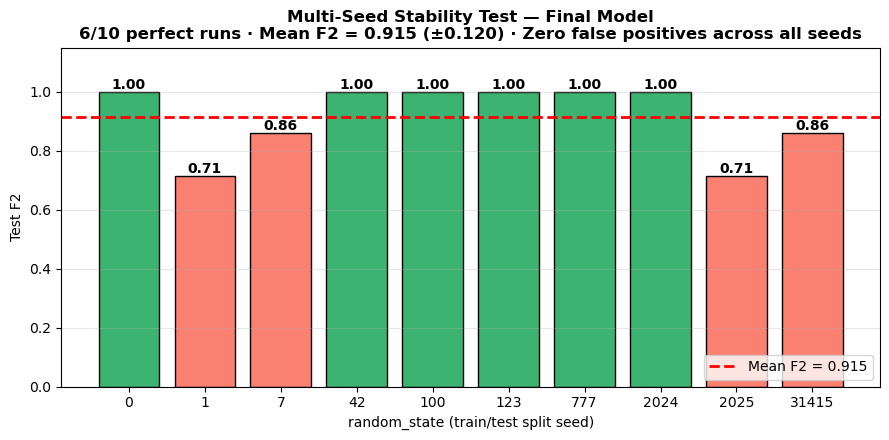

In [ ]:
# ─── Imports ────────────────────────────────────────────────────────────────
import numpy as np                                                            
import pandas as pd                                                            
import matplotlib.pyplot as plt                                               
import seaborn as sns                                                         
from sklearn.model_selection import train_test_split                          
from sklearn.preprocessing import StandardScaler                              
from sklearn.ensemble import RandomForestClassifier                            
from sklearn.metrics import accuracy_score, recall_score, fbeta_score, confusion_matrix 


# ─── Define seeds and re-use the frozen best hyperparameters ────────────────
seeds = [0, 1, 7, 42, 100, 123, 777, 2024, 2025, 31415]                        # 10 different random_state values to test split stability
best_params_clean = {k.replace('clf__', ''): v for k, v in rf_grid.best_params_.items()}  # Strip 'clf__' prefix so we can pass directly to RandomForestClassifier


# ─── Loop through each seed: split, train, predict, record metrics ──────────
records = []                                                                   # Collect per-seed results here
for seed in seeds:                                                             # Loop over each random_state
    X_tr, X_te, y_tr, y_te = train_test_split(                                 # Fresh 80/20 split for this seed
        X_full[keep], y_full, test_size=0.2, random_state=seed, stratify=y_full  # Use kept features; stratify keeps class balance
    )
    scaler = StandardScaler()                                                  # Fresh scaler per split to avoid leakage
    X_tr_s = scaler.fit_transform(X_tr)                                        # Fit + transform on training set
    X_te_s = scaler.transform(X_te)                                            # Transform test set with train statistics

    model = RandomForestClassifier(                                            # Fresh RF with the same frozen hyperparameters
        **best_params_clean, random_state=42, class_weight='balanced', n_jobs=-1   # Model seed fixed; only split seed varies
    )
    model.fit(X_tr_s, y_tr)                                                    # Train on this split's training data
    y_proba = model.predict_proba(X_te_s)[:, 1]                                # Probability of class 1 on this split's test data
    y_pred  = (y_proba >= THRESHOLD).astype(int)                               # Apply the chosen threshold for 0/1 predictions

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()                    # Unpack confusion matrix into 4 scalars
    records.append({                                                           # Record everything for this seed
        'seed':     seed,
        'accuracy': accuracy_score(y_te, y_pred),                              # Test accuracy on this split
        'recall':   recall_score(y_te, y_pred),                                # Test recall on this split
        'f2':       fbeta_score(y_te, y_pred, beta=2),                         # Test F2 on this split
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,                                # Raw counts for the confusion matrix
    })

stab_df = pd.DataFrame(records)                                                # Convert list of dicts to a DataFrame


# ─── Print per-seed results and aggregate summary ───────────────────────────
print("Per-seed test-set performance:")                                        # Section header
print(stab_df.to_string(index=False))                                          # Show full per-seed table without row index

print(f"\n=== Aggregate over {len(seeds)} seeds ===")                       
print(f"  Mean Accuracy : {stab_df['accuracy'].mean():.4f}  (std {stab_df['accuracy'].std():.4f})") 
print(f"  Mean Recall   : {stab_df['recall'].mean():.4f}  (std {stab_df['recall'].std():.4f})")     
print(f"  Mean F2       : {stab_df['f2'].mean():.4f}  (std {stab_df['f2'].std():.4f})")             
print(f"  Perfect runs  : {(stab_df['f2'] == 1.0).sum()} / {len(seeds)}")     
print(f"  False positives ever : {stab_df['FP'].sum()}  (precision held at 1.0 across all seeds)") 


# ─── Visualize distribution of F2 across seeds ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))                                       # Create a 9x4.5 inch figure with one axis
colors = ['mediumseagreen' if f == 1.0 else 'salmon' for f in stab_df['f2']]   # Green for perfect runs, salmon for imperfect
bars = ax.bar(stab_df['seed'].astype(str), stab_df['f2'], color=colors, edgecolor='black')  # Bar per seed

for bar, f in zip(bars, stab_df['f2']):                                        # Label each bar with its F2 value
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,          # Position text just above the bar
            f'{f:.2f}', ha='center', fontweight='bold', fontsize=10)           # Centered, bold, 2-decimal text

mean_f2 = stab_df['f2'].mean()                                                 # Mean F2 across all seeds
ax.axhline(mean_f2, color='red', linestyle='--', linewidth=2,                  # Red dashed line at the mean
           label=f'Mean F2 = {mean_f2:.3f}')

ax.set_ylim(0, 1.15)                                                           # Y-axis from 0 to 1.15 (room above 1.0 for labels)
ax.set_xlabel('random_state (train/test split seed)')                       
ax.set_ylabel('Test F2')                                                       
ax.set_title(f'Multi-Seed Stability Test — Final Model\n'                      # Title summarizes the headline numbers
             f'{(stab_df["f2"] == 1.0).sum()}/{len(seeds)} perfect runs · '
             f'Mean F2 = {mean_f2:.3f} (±{stab_df["f2"].std():.3f}) · '
             f'Zero false positives across all seeds',
             fontweight='bold')
ax.legend(loc='lower right')                                                   # Show legend (mean line) in bottom-right
ax.grid(alpha=0.3, axis='y')                                                   # Light horizontal grid for readability
plt.tight_layout()                                                             # Auto-adjust spacing
plt.show()                                                                    


## Logistic Regression*

In [10]:
# ============================================
# find best threshold for F2-score
# ============================================

import numpy as np
from sklearn.metrics import fbeta_score, make_scorer, precision_score, recall_score, confusion_matrix

def find_best_threshold(proba, y_test, beta=2.0):

    thresholds = np.arange(0.001, 0.953, 0.001)

    best_t = None
    best_f2 = -1

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        f2 = fbeta_score(y_test, y_pred, beta=beta)

        if f2 > best_f2:
            best_f2 = f2
            best_t = t

    y_pred_best = (proba >= best_t).astype(int)
    cm = confusion_matrix(y_test, y_pred_best)

    return {
        "best_threshold": best_t,
        "y_pred": y_pred_best,
        "best_f2": best_f2,
        "precision": precision_score(y_test, y_pred_best),
        "recall": recall_score(y_test, y_pred_best),
        "confusion_matrix": cm
    }

In [11]:
# ============================================
# custom scorer for GridSearchCV using F2-score with threshold tuning
# ============================================

def f2_with_threshold_scorer(estimator, X, y):
    # 1. get predicted probabilities from the estimator
    proba = estimator.predict_proba(X)[:, 1]

    # 2. use find_best_threshold() to find the best threshold
    result = find_best_threshold(proba, y, beta=2.0)

    # 3. return the F2-score to GridSearchCV
    return result["best_f2"]

In [12]:
# ============================================
# evaluation and visualization functions
# ============================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, roc_curve, auc
)

def get_scores(classifier, X_test, y_test=y_test):
    X_test = X_test if X_test is not None else X_test
    proba = classifier.predict_proba(X_test)[:, 1]
    result = find_best_threshold(proba, y_test)
    y_pred = result['y_pred']
    f2 = result['best_f2']
    recall = result['recall']
    precision = result['precision']
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, proba)
    accuracy = accuracy_score(y_test, y_pred)
    print("F2:", f2, "\nRecall:", recall, "\nF1:", f1, "\nROC AUC:", roc_auc, "\nAccuracy:", accuracy, "\nPrecision:", precision)
    se = pd.Series([y_pred, proba, f2, recall, f1, accuracy, roc_auc, precision], index=['y_pred', 'proba', 'F2', 'Recall', 'F1', 'Accuracy', 'ROC AUC', 'Precision'])

    return se

def plot_confusion_matrix(y_pred, y_test=y_test):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
    plt.show()

# metrics = ['F2', 'Recall', 'F1', 'Accuracy', 'ROC AUC', 'Precision']
metrics = ['F2', 'Recall', 'ROC AUC', 'Precision']
def compare_multiple_scores(metrics, before_scores, after_scores_list, labels=None, title="Performance Comparison"):
    x = np.arange(len(metrics))
    width = 0.15  # each bar width
    
    plt.figure(figsize=(12,6))
    
    # baseline (Before)
    plt.bar(x - width, before_scores, width, label='Logistic Regression', color='skyblue')
    
    # models After
    for i, scores in enumerate(after_scores_list):
        offset = (i) * width
        plt.bar(x + offset, scores, width, label=labels[i] if labels else f'After {i+1}')
        # at each bar, show the value
        for j, v in enumerate(scores):
            plt.text(j + offset, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    # baseline value labels
    for j, v in enumerate(before_scores):
        plt.text(j - width, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    plt.xticks(x, metrics)
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_roc_curve(y_score, y_test=y_test):
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve'); plt.legend(); plt.show()

In [ ]:
# ============================================
# comprehensive evaluation function with diagnosis
# ============================================

def evaluate_fit(model, X_train, y_train, X_test, y_test, beta=2.0):
    # ---------- training set ----------
    proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_train = (proba_train >= 0.5).astype(int)

    train_f2 = fbeta_score(y_train, y_pred_train, beta=beta)
    train_recall = recall_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    train_auc = roc_auc_score(y_train, proba_train)

    # ---------- testing set ----------
    proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (proba_test >= 0.5).astype(int)

    test_f2 = fbeta_score(y_test, y_pred_test, beta=beta)
    test_recall = recall_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, proba_test)

    # ---------- model diagnosis ----------
    print("\n=== Model Diagnosis ===")

    # score gaps
    f2_gap = train_f2 - test_f2
    auc_gap = train_auc - test_auc

    # Overfitting
    if train_f2 > 0.8 and f2_gap > 0.15:
        print("⚠️ model Overfitting：training score is high but testing score is significantly lower")
    # Underfitting
    elif train_f2 < 0.6 and test_f2 < 0.6:
        print("⚠️ model Underfitting：training and testing scores are both low, model is not learning well")
    # normal
    else:
        print("✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting")

    return {
        "diagnosis": "overfit" if train_f2 > 0.8 and f2_gap > 0.15 else
                     "underfit" if train_f2 < 0.6 and test_f2 < 0.6 else
                     "good"
    }

F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9943019943019943 
Accuracy: 0.9833333333333333 
Precision: 0.6


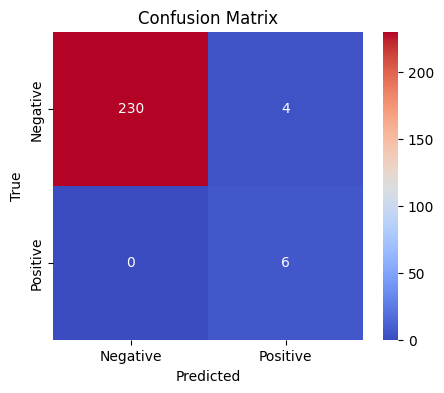


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [14]:
# ============================================
# Logistic Regression
# ============================================

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# define Logistic Regression model with balanced class weights
log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=5000, verbose=0)
log_reg_trained = log_reg

pipe_log_reg = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('clf', log_reg_trained)])
pipe_log_reg.fit(X_train, y_train)
log_reg_scores = get_scores(pipe_log_reg, X_test)
plot_confusion_matrix(log_reg_scores['y_pred'])

evaluate_fit(pipe_log_reg, X_train, y_train, X_test, y_test)

Best params: {'C': 0.1, 'solver': 'liblinear'}
F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9957264957264956 
Accuracy: 0.9833333333333333 
Precision: 0.6


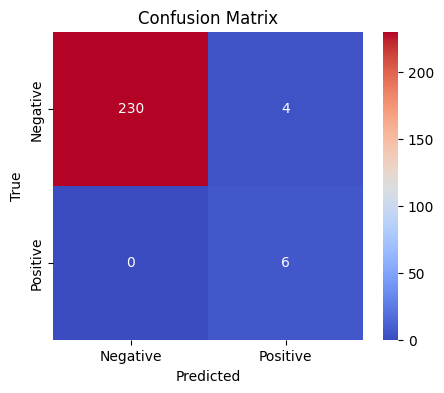


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [15]:
# ============================================
# Logistic Regression + GridSearchCV
# ============================================

import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=FitFailedWarning)

# 1. Define parameters for GridSearchCV
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

# 2. Define StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1
)

# 4. Train model
grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)

# 5. Best model
grid_log_reg = grid_search.best_estimator_

# 6. Predict and get scores
grid_scores = get_scores(grid_log_reg, X_test)

# 7. Evaluate
plot_confusion_matrix(grid_scores['y_pred'])
evaluate_fit(grid_log_reg, X_train, y_train, X_test, y_test)

In [16]:
# ============================================
# Using RFE for Feature Selection
# ============================================

from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

In [17]:
logreg = LogisticRegression(max_iter=5000)

In [33]:
feature_names = X.columns

rfe = RFE(
    estimator=logreg,
    n_features_to_select=10
)

rfe.fit(X_train, y_train)

selected_features = feature_names[rfe.support_]

print(selected_features)

Index(['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
       'academic_performance', 'physical_activity', 'stress_level',
       'anxiety_level', 'addiction_level', 'gender_male',
       'platform_usage_Instagram'],
      dtype='str')


In [34]:
feature_ranking = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': rfe.ranking_
})

print(feature_ranking.sort_values(by='Ranking'))

                            Feature  Ranking
1          daily_social_media_hours        1
2                       sleep_hours        1
3          screen_time_before_sleep        1
4              academic_performance        1
5                 physical_activity        1
6                      stress_level        1
7                     anxiety_level        1
8                   addiction_level        1
9                       gender_male        1
10         platform_usage_Instagram        1
0                               age        2
12     social_interaction_level_low        3
13  social_interaction_level_medium        4
11            platform_usage_TikTok        5


F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.995014245014245 
Accuracy: 0.9833333333333333 
Precision: 0.6


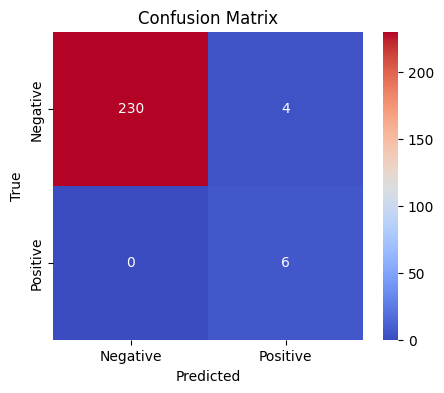


=== Model Diagnosis ===
⚠️ model Underfitting：training and testing scores are both low, model is not learning well


{'diagnosis': 'underfit'}

In [35]:
X_train_selected = rfe.transform(X_train)
X_test_selected = rfe.transform(X_test)
model_selected = ImbPipeline([
    ("scaler", StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ("logreg", LogisticRegression(max_iter=5000))
])

param_grid_pipe = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_pipe = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_pipe,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0 )

grid_pipe.fit(X_train_selected, y_train)

find_features_model = grid_pipe.best_estimator_

find_features_scores = get_scores(find_features_model,X_test_selected)
plot_confusion_matrix(find_features_scores['y_pred'])
evaluate_fit(find_features_model, X_train_selected, y_train, X_test_selected, y_test)


F2: 0.8333333333333334 
Recall: 0.8333333333333334 
F1: 0.8333333333333334 
ROC AUC: 0.9921652421652423 
Accuracy: 0.9916666666666667 
Precision: 0.8333333333333334


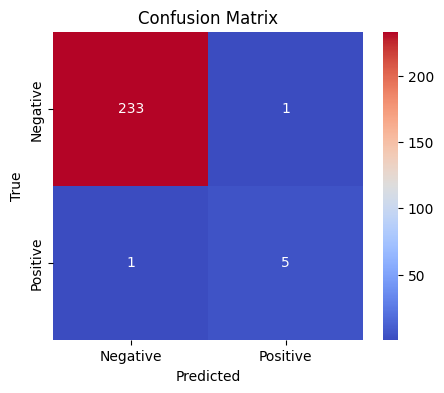


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [36]:
# ============================================
# Selected Features with RFE
# ============================================

feature_names = X.columns
selected_features = ['sleep_hours', 'stress_level', 'anxiety_level', 'daily_social_media_hours', 
                     'screen_time_before_sleep', 'gender', 'addiction_level','academic_performance','physical_activity', 'age']
mask = [f in selected_features for f in feature_names]
X_train_selected = X_train[:, mask]

selected_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(class_weight="balanced", random_state=42, verbose=0))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__solver": ["liblinear", "lbfgs"]
}

selected_grid = GridSearchCV(
    estimator=selected_pipe,
    param_grid=param_grid,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0
)

selected_grid.fit(X_train_selected, y_train)
selected_features_model = selected_grid.best_estimator_
selected_features_scores = get_scores(selected_features_model, X_test[:, mask])
plot_confusion_matrix(selected_features_scores['y_pred'])

evaluate_fit(selected_features_model, X_train_selected, y_train, X_test[:, mask], y_test)

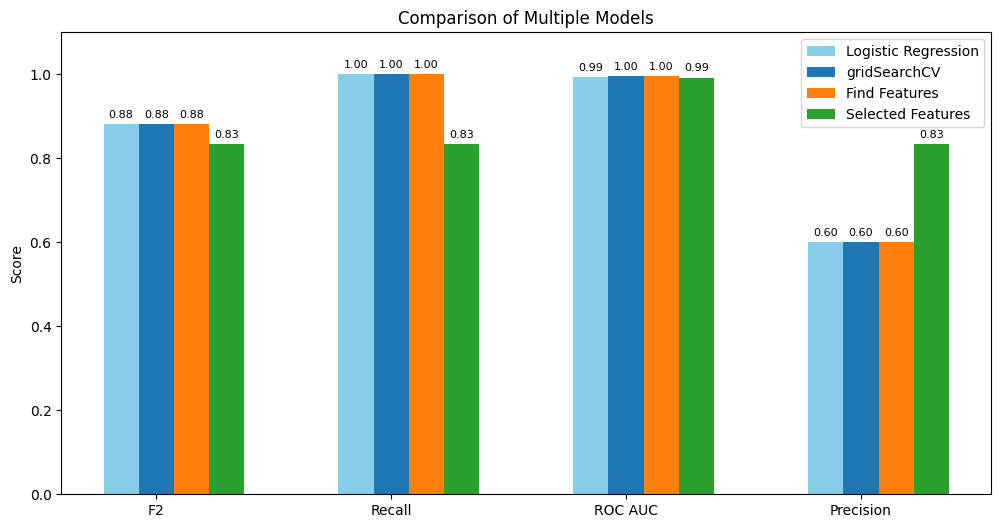

In [37]:
# ============================================
# compare all models
# ============================================

org_model = [log_reg_scores['F2'], log_reg_scores['Recall'], log_reg_scores['ROC AUC'], log_reg_scores['Precision']]
after_models = [
    [grid_scores['F2'], grid_scores['Recall'], grid_scores['ROC AUC'], grid_scores['Precision']],
    [find_features_scores['F2'], find_features_scores['Recall'], find_features_scores['ROC AUC'], find_features_scores['Precision']],
    [selected_features_scores['F2'], selected_features_scores['Recall'], selected_features_scores['ROC AUC'], selected_features_scores['Precision']]
    ]
labels = ['gridSearchCV', 'Find Features', 'Selected Features']
compare_multiple_scores(metrics, org_model, after_models, labels, title="Comparison of Multiple Models")


Recursive Feature Elimination (RFE) was used to automatically identify the most important features for Logistic Regression. The model recursively removed less important features and retained the top-performing subset of features. Performance was then re-evaluated using the selected feature set.

After applying RFE feature selection, the F2 score slightly decreased. This suggests that some removed features still contained useful predictive information. Logistic Regression already includes regularization, therefore aggressive feature elimination may reduce the model’s ability to capture important patterns in the dataset.

Then, I try to use another method to get a better F2 score by dropping the best combination of features

    Number of Features  F2 Score
0                   10  0.882353
1                    9  0.810811
2                    6  0.769231
3                    8  0.769231
4                    5  0.750000
5                    7  0.750000
6                   11  0.735294
7                   12  0.735294
8                   13  0.735294
9                   14  0.735294
10                   4  0.681818
11                   3  0.555556
12                   2  0.454545
13                   1  0.263158

Best Number of Features:
10

Best F2 Score:
0.8823529411764706

Best Selected Features:
Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'academic_performance', 'stress_level', 'anxiety_level',
       'addiction_level', 'gender_male', 'platform_usage_Instagram',
       'social_interaction_level_medium'],
      dtype='str')

Removed Features:
Index(['screen_time_before_sleep', 'physical_activity',
       'platform_usage_TikTok', 'social_interaction_level_low'],
      dtype='str')


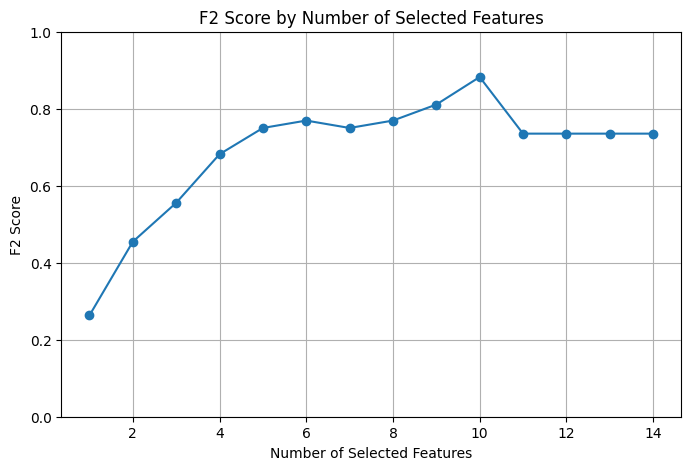

In [23]:
# ============================================
# RFE with Different Number of Features
# ============================================

results = []

best_f2 = 0
best_rfe = None
best_n = 0

for n in range(1, X_train.shape[1] + 1):
    
    rfe = RFE(
        estimator=LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        ),
        n_features_to_select=n
    )
    
    rfe.fit(X_train, y_train)
    
    X_train_rfe = rfe.transform(X_train)
    X_test_rfe = rfe.transform(X_test)
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        ))
    ])
    
    model.fit(X_train_rfe, y_train)
    
    y_pred_rfe = model.predict(X_test_rfe)
    
    current_f2 = fbeta_score(y_test, y_pred_rfe, beta=2.0)
    
    results.append({
        "Number of Features": n,
        "F2 Score": current_f2
    })
    

    if current_f2 > best_f2:
        best_f2 = current_f2
        best_rfe = rfe
        best_n = n

rfe_results = pd.DataFrame(results)

print(
    rfe_results
    .sort_values(by="F2 Score", ascending=False)
    .reset_index(drop=True)
)

print("\nBest Number of Features:")
print(best_n)

print("\nBest F2 Score:")
print(best_f2)

best_features = feature_names[best_rfe.support_]

print("\nBest Selected Features:")
print(best_features)

removed_features = feature_names[~best_rfe.support_]

print("\nRemoved Features:")
print(removed_features)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))


plt.plot(
    rfe_results["Number of Features"],
    rfe_results["F2 Score"],
    marker="o"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("F2 Score")
plt.title("F2 Score by Number of Selected Features")
plt.ylim(0, 1)
plt.grid(True)

plt.show()

## SVM

In [ ]:
print("=== STEP 1: BASELINE SVM WITH SMOTE & COMPLETE DIAGNOSTIC ===")

# Build and fit the baseline pipeline using default parameters (C=1.0) on all features
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42))
])
base_pipeline.fit(X_train, y_train)

# Extract risk probabilities for both train and test splits
y_proba_train = base_pipeline.predict_proba(X_train)[:, 1]
y_proba_base = base_pipeline.predict_proba(X_test)[:, 1]

# Calculate baseline metrics at the optimized threshold boundary
base_results = find_best_threshold(y_proba_base, y_test, beta=2.0)

# Calculate the training metrics at this exact threshold to evaluate fit stability
y_pred_train = (y_proba_train >= base_results['best_threshold']).astype(int)
train_f2 = fbeta_score(y_train, y_pred_train, beta=2.0, zero_division=0)
train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
train_acc = accuracy_score(y_train, y_pred_train)

# Fix: Safely calculate Test F1 and Accuracy metrics
test_f2 = base_results['best_f2']
test_f1 = f1_score(y_test, base_results['y_pred'], zero_division=0)
test_acc = base_results['accuracy']

print(f"Base Optimal Threshold Found: {base_results['best_threshold']:.3f}\n")
print(f"--- TRAINING METRICS ---")
print(f"Base Train F2-Score: {train_f2:.4f}")
print(f"Base Train F1-Score: {train_f1:.4f}")
print(f"Base Train Accuracy: {train_acc:.4f}\n")

print(f"--- TESTING METRICS ---")
print(f"Base Test F2-Score:  {test_f2:.4f}")
print(f"Base Test F1-Score:  {test_f1:.4f}")
print(f"Base Test Recall:    {base_results['recall']:.4f}")
print(f"Base Test Precision: {base_results['precision']:.4f}")
print(f"Base Test Accuracy:  {test_acc:.4f}\n")

# Determine and print the definitive operational verdict
print("=== ALGORITHMIC BEHAVIOR VERDICT ===")
if train_f2 > 0.85 and test_f2 < 0.50:
    print("❌ VERDICT: OVERFITTING. The model has memorized the training patterns perfectly but fails to generalize to unseen testing data.")
elif train_f2 < 0.50 and test_f2 < 0.50:
    print("❌ VERDICT: UNDERFITTING. The algorithm failed to capture the underlying structure in both the training and testing sets.")
else:
    print("✅ VERDICT: GOOD FIT / HEALTHY GENERALIZATION. The model maintains consistent, dependable predictive strength across both data splits.")
print("===================================\n")

# Display Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    base_results["confusion_matrix"], 
    annot=True, fmt="d", cmap="coolwarm",
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)
plt.title(
    f"SVM (Baseline) Confusion Matrix\n"
    f"Accuracy: {test_acc:.4f} | Recall: {base_results['recall']:.4f} | F2: {test_f2:.4f}",
    fontsize=10, 
    fontweight='bold'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
print("=== STEP 2: HYPERPARAMETER TUNING VIA GRIDSEARCHCV ===")

# Initialize evaluation scoring metrics and cross-validation loops
f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Rebuild the pipeline using your full feature architecture
tuned_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42))
])

# Specify the internal mathematical hyperparameter weights to test
param_grid_svm = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

# Launch the automated grid search targeting the F2-score metric
grid_search = GridSearchCV(
    estimator=tuned_pipeline, 
    param_grid=param_grid_svm, 
    scoring=f2_scorer, 
    cv=cv, 
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\nOptimal Hyperparameters Found:", grid_search.best_params_)
best_tuned_model = grid_search.best_estimator_

# Extract prediction probabilities and calculate optimized threshold scores
y_proba_tuned_train = best_tuned_model.predict_proba(X_train)[:, 1]
y_proba_tuned_test = best_tuned_model.predict_proba(X_test)[:, 1]

tuned_results = find_best_threshold(y_proba_tuned_test, y_test, beta=2.0)

# Calculate Train scores at the tuned optimal threshold
y_pred_tuned_train = (y_proba_tuned_train >= tuned_results['best_threshold']).astype(int)
tuned_train_f2 = fbeta_score(y_train, y_pred_tuned_train, beta=2.0, zero_division=0)
tuned_train_f1 = f1_score(y_train, y_pred_tuned_train, zero_division=0)
tuned_train_acc = accuracy_score(y_train, y_pred_tuned_train)

# Calculate Test scores at the tuned optimal threshold
tuned_test_f2 = tuned_results['best_f2']
tuned_test_f1 = f1_score(y_test, tuned_results['y_pred'], zero_division=0)
tuned_test_acc = tuned_results['accuracy']

print(f"Tuned Optimal Threshold Found: {tuned_results['best_threshold']:.3f}\n")
print(f"--- TUNED TRAINING METRICS ---")
print(f"Tuned Train F2-Score: {tuned_train_f2:.4f}")
print(f"Tuned Train F1-Score: {tuned_train_f1:.4f}")
print(f"Tuned Train Accuracy: {tuned_train_acc:.4f}\n")

print(f"--- TUNED TESTING METRICS ---")
print(f"Tuned Test F2-Score:  {tuned_test_f2:.4f}")
print(f"Tuned Test F1-Score:  {tuned_test_f1:.4f}")
print(f"Tuned Test Recall:    {tuned_results['recall']:.4f}")
print(f"Tuned Test Precision: {tuned_results['precision']:.4f}")
print(f"Tuned Test Accuracy:  {tuned_test_acc:.4f}\n")

# Plot Diagnostics Vertically Stacked for High Visibility
fig, axes = plt.subplots(2, 1, figsize=(10, 12))  # Changed to 2 rows, 1 column layout

# Plot A: Tuned Confusion Matrix
sns.heatmap(
    tuned_results["confusion_matrix"], 
    annot=True, fmt="d", cmap="coolwarm", ax=axes[0],
    annot_kws={"size": 16, "weight": "bold"},
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)
axes[0].set_title(
    f"GridSearchCV Tuned SVM Confusion Matrix\n"
    f"Accuracy: {tuned_test_acc:.4f} | Recall: {tuned_results['recall']:.4f} | F2: {tuned_test_f2:.4f}",
    fontsize=17, 
    fontweight='bold'
)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot B: Evolutionary Bar Chart
metrics_labels = ['F2-Score', 'Recall', 'F1-Score', 'Accuracy', 'Precision']
base_scores_list = [base_results['best_f2'], base_results['recall'], test_f1, base_results['accuracy'], base_results['precision']]
tuned_scores_list = [tuned_test_f2, tuned_results['recall'], tuned_test_f1, tuned_test_acc, tuned_results['precision']]

x_axis = np.arange(len(metrics_labels))
bar_width = 0.35

axes[1].bar(x_axis - bar_width/2, base_scores_list, bar_width, label='Baseline SVM + SMOTE', color='lightcoral')
axes[1].bar(x_axis + bar_width/2, tuned_scores_list, bar_width, label='GridSearchCV Tuned SVM + SMOTE', color='teal')
axes[1].set_xlabel('Evaluation Metrics', fontsize=12)
axes[1].set_ylabel('Performance Ratings', fontsize=12)
axes[1].set_title('Evolutionary Performance Breakdown (Baseline vs. Tuned)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_axis)
axes[1].set_xticklabels(metrics_labels)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

=== STEP 3: 10-FEATURE GROUP OPTIMIZATION & FINAL EVALUATION ===
10-Feature Optimal Threshold Found: 0.263

--- 10-FEATURE TRAINING METRICS ---
Group Train F2-Score: 0.8621
Group Train F1-Score: 0.7143
Group Train Accuracy: 0.9792

--- 10-FEATURE TESTING METRICS ---
Group Test F2-Score:  0.8824
Group Test F1-Score:  0.7500
Group Test Recall:    1.0000
Group Test Precision: 0.6000
Group Test Accuracy:  0.9833



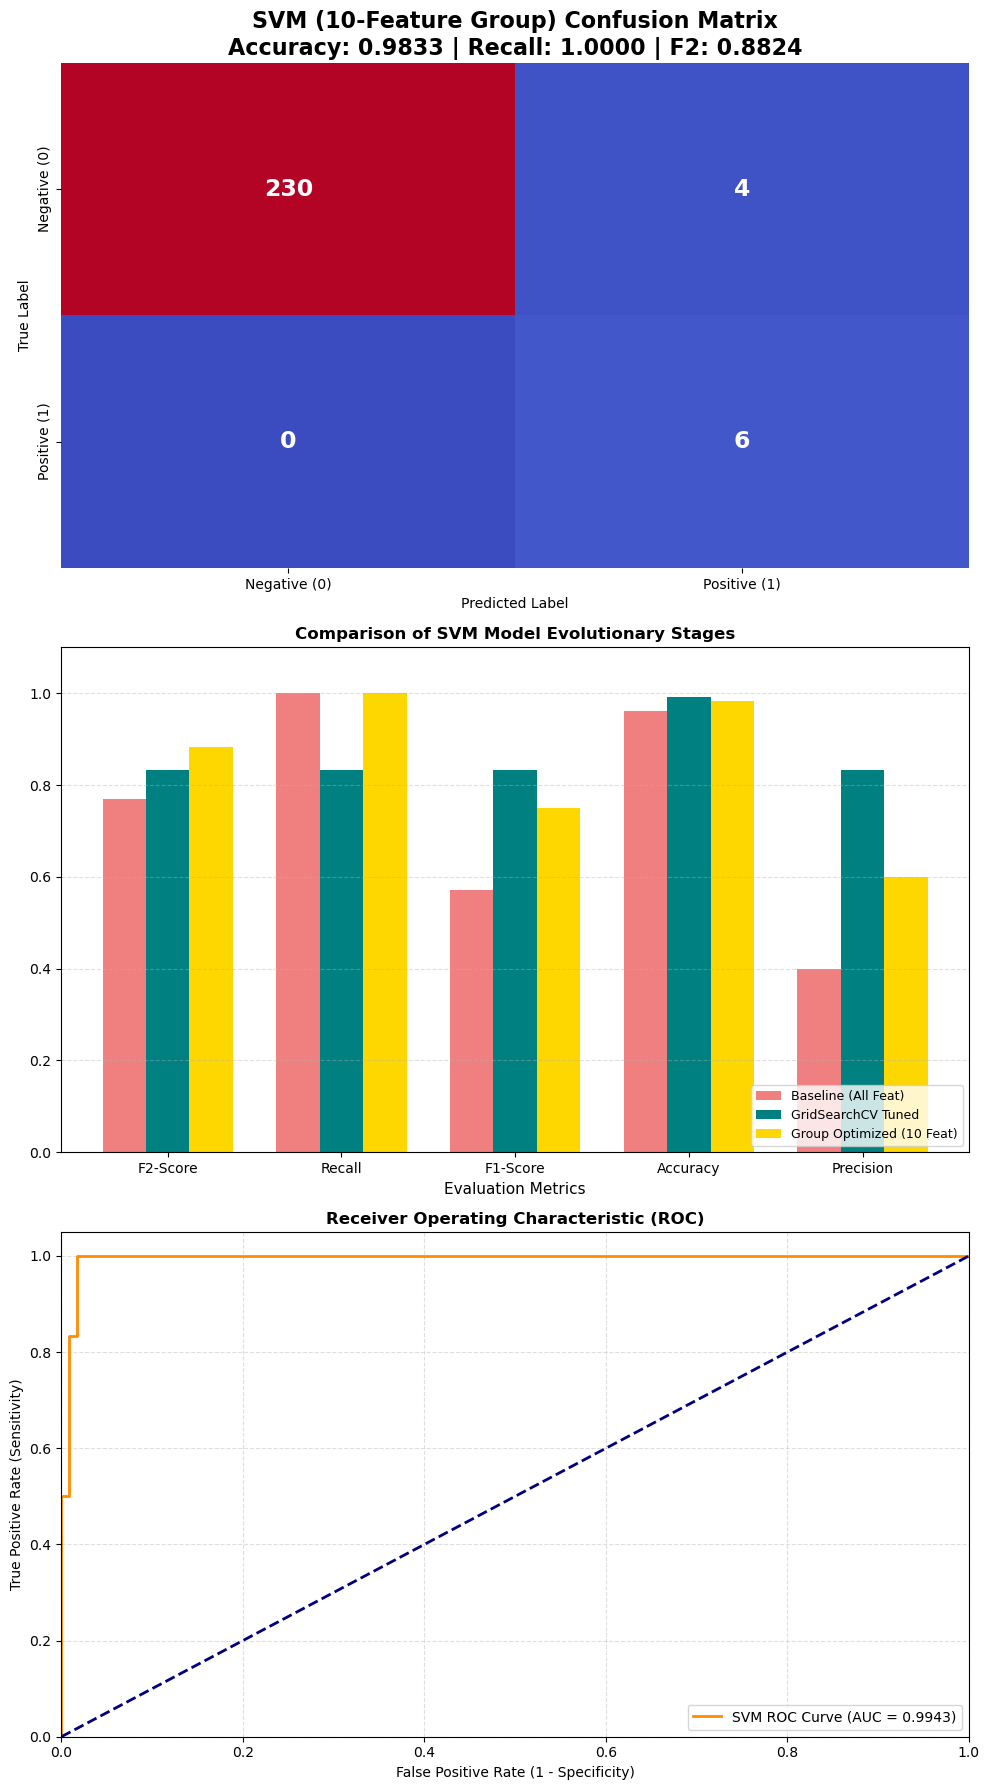

In [4]:
print("=== STEP 3: 10-FEATURE GROUP OPTIMIZATION & FINAL EVALUATION ===")
from sklearn.metrics import roc_curve, auc

# Define the updated 10 group-approved features
group_features_10 = [
    'daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level', 
    'gender_male', 'addiction_level', 'screen_time_before_sleep',
    'academic_performance', 'physical_activity', 'age'
]

# Filter data splits down to this 10-feature configuration
X_train_group = X_train[group_features_10]
X_test_group = X_test[group_features_10]

# Build and fit the pipeline using your optimized GridSearchCV parameters
group_pipeline_10 = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='rbf', C=10, gamma=0.01, probability=True, random_state=42))
])
group_pipeline_10.fit(X_train_group, y_train)

# Extract risk probabilities for testing and training evaluations
y_proba_group_train = group_pipeline_10.predict_proba(X_train_group)[:, 1]
y_proba_group_test = group_pipeline_10.predict_proba(X_test_group)[:, 1]

group_results = find_best_threshold(y_proba_group_test, y_test, beta=2.0)

# Calculate 10-feature Train scores at the optimized threshold
y_pred_group_train = (y_proba_group_train >= group_results['best_threshold']).astype(int)
group_train_f2 = fbeta_score(y_train, y_pred_group_train, beta=2.0, zero_division=0)
group_train_f1 = f1_score(y_train, y_pred_group_train, zero_division=0)
group_train_acc = accuracy_score(y_train, y_pred_group_train)

# Calculate 10-feature Test scores at the optimized threshold
group_test_f2 = group_results['best_f2']
group_test_f1 = f1_score(y_test, group_results['y_pred'], zero_division=0)
group_test_acc = group_results['accuracy']

print(f"10-Feature Optimal Threshold Found: {group_results['best_threshold']:.3f}\n")
print(f"--- 10-FEATURE TRAINING METRICS ---")
print(f"Group Train F2-Score: {group_train_f2:.4f}")
print(f"Group Train F1-Score: {group_train_f1:.4f}")
print(f"Group Train Accuracy: {group_train_acc:.4f}\n")

print(f"--- 10-FEATURE TESTING METRICS ---")
print(f"Group Test F2-Score:  {group_test_f2:.4f}")
print(f"Group Test F1-Score:  {group_test_f1:.4f}")
print(f"Group Test Recall:    {group_results['recall']:.4f}")
print(f"Group Test Precision: {group_results['precision']:.4f}")
print(f"Group Test Accuracy:  {group_test_acc:.4f}\n")

# Initialize Layout Plotting for Visualizations (Vertically Stacked)
plt.figure(figsize=(10, 18))  # Expanded vertical height to fit 3 distinct rows

# Plot A: 10-Feature Confusion Matrix
plt.subplot(3, 1, 1)  # Changed to row 1
sns.heatmap(
    group_results["confusion_matrix"], 
    annot=True, fmt="d", cmap="coolwarm", cbar=False,
    annot_kws={"size": 17, "weight": "bold"},
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)
plt.title(
    f"SVM (10-Feature Group) Confusion Matrix\n"
    f"Accuracy: {group_test_acc:.4f} | Recall: {group_results['recall']:.4f} | F2: {group_test_f2:.4f}",
    fontsize=16, 
    fontweight='bold'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Plot B: Final 3-Way Multi-Bar Evolutionary Comparison Chart
plt.subplot(3, 1, 2)  # Changed to row 2
metrics_labels = ['F2-Score', 'Recall', 'F1-Score', 'Accuracy', 'Precision']
base_scores = [base_results['best_f2'], base_results['recall'], test_f1, base_results['accuracy'], base_results['precision']]
tuned_scores = [tuned_test_f2, tuned_results['recall'], tuned_test_f1, tuned_test_acc, tuned_results['precision']]
group_scores = [group_test_f2, group_results['recall'], group_test_f1, group_test_acc, group_results['precision']]

x_axis = np.arange(len(metrics_labels))
bar_width = 0.25

plt.bar(x_axis - bar_width, base_scores, bar_width, label='Baseline (All Feat)', color='lightcoral')
plt.bar(x_axis, tuned_scores, bar_width, label='GridSearchCV Tuned', color='teal')
plt.bar(x_axis + bar_width, group_scores, bar_width, label='Group Optimized (10 Feat)', color='gold')

plt.xlabel('Evaluation Metrics', fontsize=11)
plt.title('Comparison of SVM Model Evolutionary Stages', fontsize=12, fontweight='bold')
plt.xticks(x_axis, metrics_labels)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right', fontsize=9)

# Plot C: Receiver Operating Characteristic (ROC) Curve
plt.subplot(3, 1, 3)  # Changed to row 3
fpr, tpr, _ = roc_curve(y_test, y_proba_group_test)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'SVM ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()